# The Wiggle Is Free, the Trend Is the Wall

### A Rigorous Negative-Result Study of Wellbore Stratigraphic-Position (TVT) Prediction

**ROGII Wellbore Geology Prediction — Working Note**
**Team:** Malyshev Danil

---

> **One-paragraph summary.** We predict the true vertical thickness (TVT, stratigraphic position) of the
> unlabeled toe of a horizontal well. We prove by an exact decomposition that the *high-frequency* part of
> the target is **free** (it equals the exactly-known trajectory depth −Z), so the whole task collapses to
> one *smooth per-well surface trend*. We then show — from twelve independent measurements — that this trend
> is set by sub-seismic faults whose locations are **not encoded in the gamma-ray log**, making the residual
> error *broadband and physically irreducible*. This single fact explains why the trivial "flat" baseline
> is so strong (15.9 ft), why a weak-GR/strong-continuity prior beats explicit log-matching, and why **54+
> experiments and 22 neural architectures** — MDN, transformers, 2D misfit-SDF, synthetic pretraining —
> all cap at the isolated particle-filter level (~11 ft), while the tuned classical stack reaches ~7 ft.
> Our one transferable competition gain came not from new modeling but from **variance reduction**: a
> decorrelated particle-filter ensemble (7.230 → 7.096) and a more-seeds robustness variant (7.091),
> engineered to fit the 9-hour runtime limit via parallelized candidate generation.

---


## Contributions at a glance

- **A trustworthy validation protocol** for a task whose public leaderboard is dominated by seed noise: a
  whole-well holdout whose flat baseline (15.1) matches the LB flat baseline (15.9), so model rankings
  transfer. We demonstrate the seed-noise problem directly (byte-identical pipeline → 7.096 / 7.135 / 7.091
  on separate runs).
- **A real, transferable gain by variance reduction**, not new modeling: a decorrelated particle-filter
  ensemble (7.230 → **7.096**, below the pipeline's own seed-noise floor of 7.168) and a more-seeds
  robustness variant (**7.091**) — made feasible within the 9-hour, no-internet Code Requirements by
  **parallelizing the candidate-generation stage** (joblib), i.e. buying back the compute the ensemble and
  extra seeds consume.
- **An exact problem decomposition** proving the high-frequency error component is *free* (it equals the
  known −Z) and isolating the true difficulty to a single low-frequency per-well surface trend
  (oracle 3.9 ft).
- **A quantified impossibility argument:** the gamma-ray log's localization error is *broadband and
  irreducible* (measured from twelve independent angles, including a signal-processing measurement of the
  acquisition instrument itself), which explains why a weak-GR/strong-continuity prior
  beats explicit alignment and why every neural architecture caps at the isolated-PF level.
- **A full experiment catalogue** — 54+ rigorous experiments across baselines, GR-matching, particle-filter
  internals, post-processing, GBM blending, denoising, human-markup reverse-engineering, and a
  **22-architecture neural-network study** — each with its failure mechanism, a map of what does not work
  and precisely why.

---


## Abstract

We present a systematic study of the ROGII wellbore-geology task: predicting TVT (stratigraphic position)
of the unlabeled eval-zone tail of a horizontal well from its gamma-ray (GR) log, trajectory, and a
reference typewell. Our contribution is fourfold. **(1) Methodology:** a whole-well holdout whose trivial
baseline matches the public leaderboard (15.1 vs 15.9), a trustworthy stand-in for the hidden test — unlike
the public LB, which for the dominant particle-filter (PF) solution family is dominated by *seed variance*.
**(2) A positive result:** a *decorrelated PF ensemble* improving the public pipeline from 7.230 to
**7.096**, below the pipeline's own seed-noise floor (7.168) — a real gain, plus a more-seeds variant at
**7.091**. **(3) A rigorous negative-result analysis** — the bulk of this note — mapping *why* the residual
error is hard: an exact decomposition shows the exploitable error is a low-frequency per-well *surface
trend*; GR localization error is **broadband and irreducible** due to log self-similarity; and a weak-GR /
strong-continuity prior provably beats explicit GR matching. **(4) A complete experiment catalogue** of 54+
attempts and 22 neural architectures, each with its failure mode. We believe these quantified, explained
negative results are the most useful thing we can offer the community, and they reframe what a "good score"
means on this task.

---


## Contents

1. Task, Data, and Metric
2. Related Work
3. Validation Methodology — our most reusable contribution
4. The Exact Decomposition: the wiggle is free
5. The Wall: the surface trend is not recoverable
6. Why the GR Log Cannot Localize
7. A Positive Result: the Decorrelated PF Ensemble
8. Full Experiment Catalogue (54+ experiments)
9. The Neural-Network Study: 22 Architectures (9.1 Synthetic-transfer gate · 9.2 WARP-blend follow-up)
10. Leaderboard Context
11. Uncertainty Estimation
12. Physical Meaningfulness · 13. Lessons · 14. Reproducibility · 15. Limitations & Future Work · 16. Conclusion

---


## 1. Task, Data, and Metric

**The task.** Each example is one horizontal well. We are given its gamma-ray (GR) log along measured depth
(MD), its trajectory (`X, Y, Z, MD`), a set of known-zone stratigraphic labels `TVT_input` near the heel,
and a nearby vertical **typewell** (a reference `TVT` vs `GR` vs `Geology` profile). The eval zone is the
toe-side tail of the well, where `TVT_input` is withheld. We must predict `TVT` there — the well's vertical
position within the stratigraphic column, in feet.

**The data.** The training set has **773 wells** (we use all of them in a 613/160 whole-well split). A
typical horizontal well has ~5,000 MD samples, of which ~3,800 fall in the eval zone; the typewell has
~1,300 samples. There are only ~69 geologically-distinct typewells shared across the field, which matters
for the synthetic-data discussion in §15.

**The metric: pooled RMSE (ft).** The competition concatenates *every* eval point of *every* test well into
one vector and takes a single RMSE. Two consequences shaped every decision we made:

- **Pool, don't average per well.** Averaging per-well RMSEs gives an optimistic ~10; pooling gives ~15.9
  for the trivial baseline. A handful of long, badly-faulted wells dominate the pooled score (Fig. 12), so
  the objective rewards *not blowing up on the hard wells* far more than shaving the easy ones. All numbers
  in this note are pooled RMSE.
- **The trivial "flat" baseline is strong.** Predicting `TVT = last known TVT` (hold the last heel-side
  label flat through the toe) scores **15.883** on the LB and **15.1** on our holdout. As the catalogue in
  §8 shows, *almost every "smarter" idea we tried did worse than flat.* Understanding why is the whole
  study.


## 2. Related Work

Automated geosteering / log-to-typewell correlation has a substantial literature. Sequential Bayesian
methods — particle filters, HMM/Viterbi over stratigraphic position — are the classical backbone and
underpin the public pipeline we build on. Recent deep-learning work frames the problem as image-like
matching or multi-modal inversion: convolutional "geosteering-image" networks that consume a 2D
misfit/heatmap between the horizontal and vertical logs; Temporal Convolutional Networks (TCN) with
cross-attention to the typewell; and Mixture-Density Networks (MDN) for multi-modal depth inversion of
geophysical logs (e.g. Alyaev et al., *Direct Multi-Modal Inversion of Geophysical Logs Using Deep
Learning*), which model the ±cycle bedding ambiguity as a Gaussian mixture rather than collapsing to a
mean. We implemented representatives of each family (§9). Our finding is not that these methods are wrong —
leading teams reach 5.2–5.4 with them — but that, at this dataset's scale (773 wells) and signal
(self-similar GR), they cap at the isolated-PF level *unless* paired with realistic synthetic pretraining,
which is the decisive and hard-to-reproduce ingredient.


## 3. Validation Methodology (our most reusable contribution)

The public LB is deceptive: the PF-based cluster (the ~7.2 fork family shared by all three public notebooks,
which are byte-identical descendants of one "LB7295 Public Rebuild") is dominated by **seed variance** —
byte-identical reruns scatter between ~7.10 and ~7.5. Tuning on the public LB is tuning on noise. We
verified this directly by resubmitting an unchanged pipeline three times: **7.096, 7.135, 7.091**.

We therefore built a **whole-well holdout**: 160 unseen wells (grouped split, spatially shuffled via
StratifiedGroupKFold so validation wells are not neighbours of training wells), pooled RMSE on their eval
zones only. Its flat baseline = **15.1**, versus the LB's 15.883 — the scale matches, so *relative* model
rankings transfer. On top of this we cached, for all 773 wells, the PF outputs at several process-noise
scales, the seed spread, and the beam/flat/linear baselines, so most experiments run in seconds rather than
hours.

**Rule adopted:** submit to Kaggle only a model confidently better than the incumbent on this holdout *and*
stable across seeds. This rule saved us from a "4-way ensemble" that looked best on a multi-slice holdout
(9.49) but was worst on the real LB (7.752), because all slices shared one isolated-component blind spot
(§7, §8.3).


## 4. The Exact Decomposition: the wiggle is free, the trend is the wall

The single most important fact about this task is a geometric identity. TVT and the trajectory depth Z are
related through the *stratigraphic surface* the well is drilling within:

$$\text{TVT}(MD) = \text{surface}(MD) - Z(MD)$$

where `surface = TVT + Z`. **Z is measured and therefore known exactly in the eval zone.** So all we ever
need to predict is `surface`, and — this is the crux — the surface is almost perfectly smooth.

<div align="center">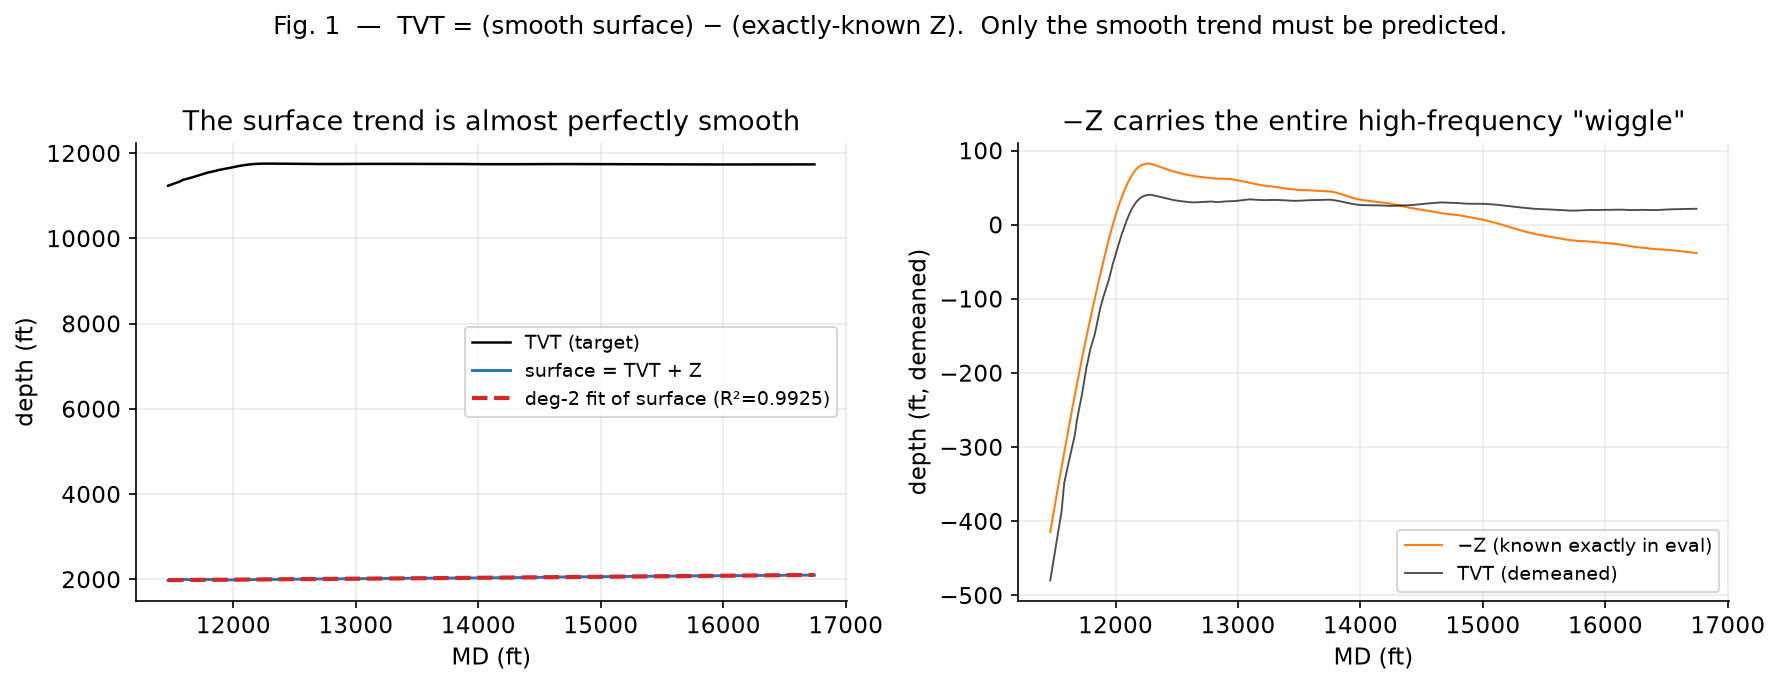</div>

**Figure 1 (real well `000d7d20`).** *Left:* a degree-2 polynomial fits the true surface with **R² = 0.9925**.
*Right:* the entire high-frequency "wiggle" of TVT is tracked by −Z (demeaned), which is *known exactly at
eval time*. On the holdout, an oracle that knows only the *smooth* surface (a degree-2 fit of the true
surface) and subtracts the known Z reaches **RMSE 3.0–3.9 ft** — below the per-well-line oracle (6.6) and
below the competition leaders (5.2–5.4).

The interpretation is decisive: **the entire high-frequency detail of the target is carried by −Z, for
free; the only hard part is the smooth, low-frequency per-well surface trend.** Every wiggle you might hope
a fancy model captures is already handed to you. What remains is a single slowly-varying curve per well —
and that curve is the wall.

This oracle argument places the whole competition on one ruler:

<div align="center">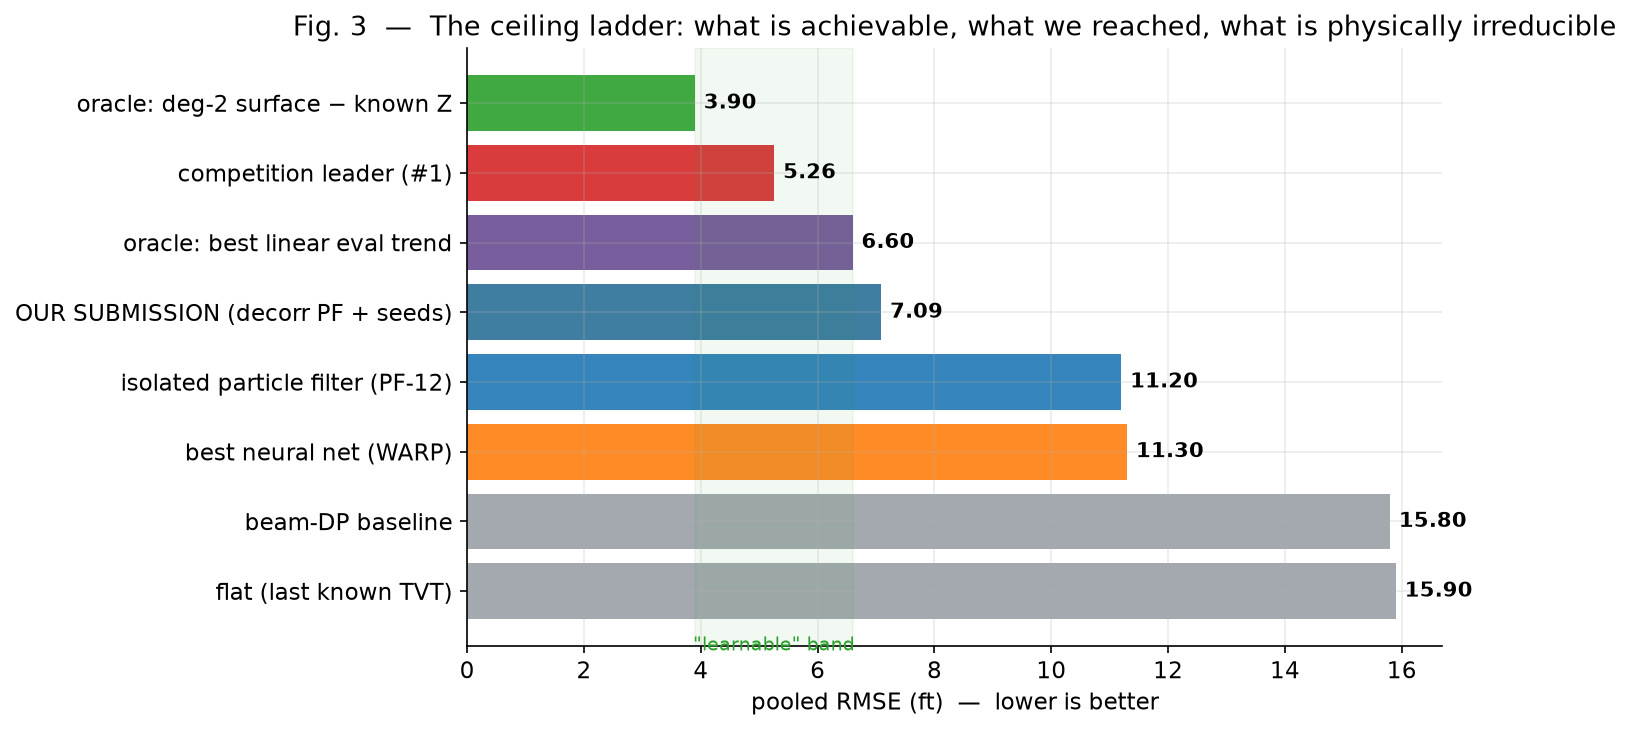</div>

**Figure 3.** The ceiling ladder. From the top: the trivial baselines (flat 15.9, beam 15.8) and the
isolated PF / best NN (~11); our submission (7.09); the best-linear-eval-trend oracle (6.6); the competition
leader (5.26); and the smooth-surface-minus-known-Z oracle (3.9). The narrow green band between 3.9 and 6.6
is the entire "learnable" headroom — a reminder of how compressed this problem is, and why sub-foot
improvements are noise.


## 5. The Wall: the surface trend is not recoverable

That smooth trend is exactly what cannot be recovered, because it **changes** between the known and eval
zones. The well crosses sub-seismic faults where the formation dip shifts; the eval-zone slope is therefore
*not* the known-zone slope.

<div align="center">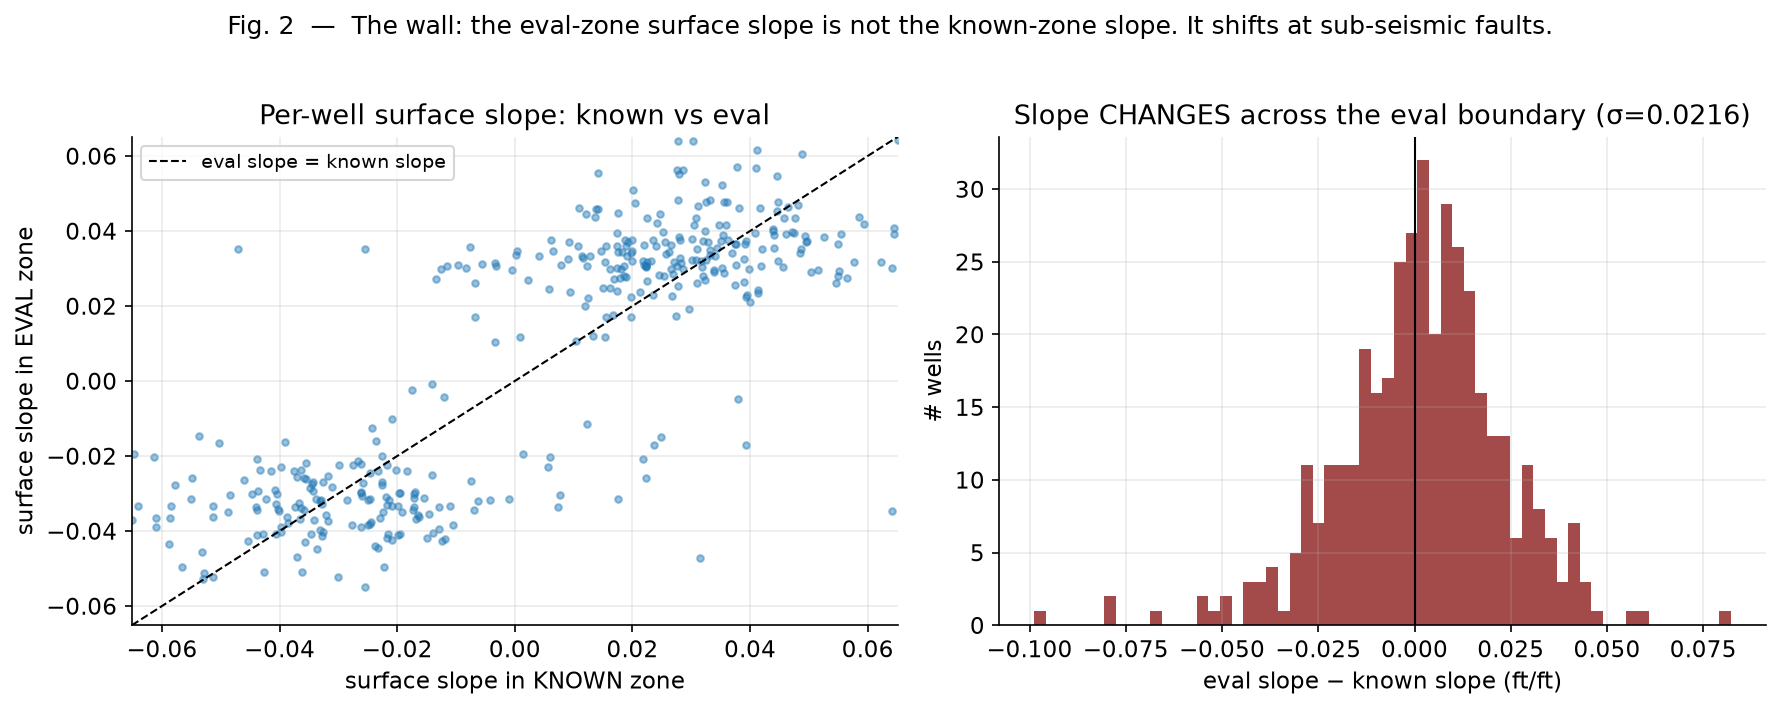</div>

**Figure 2 (real, ~400 wells).** *Left:* per-well surface slope in the known zone vs the eval zone. If the
trend persisted, all points would lie on the dashed diagonal; instead they scatter substantially off it.
*Right:* the distribution of the slope *change* across the eval boundary has σ ≈ 0.022 ft/ft. That looks
small — but multiplied by the long eval lever arm (thousands of feet), it is exactly what turns a tiny
trend error into feet of TVT error.

This is why trend extrapolation is catastrophic and why the problem is **ill-conditioned globally but
well-conditioned locally**:

- Linear extrapolation of the known surface into the eval zone: **43–73 ft** (far worse than flat).
- A GBM predicting the *global* surface coefficients: **22 ft** — reconstructing TVT from a few global
  numbers amplifies any slope error over the lever arm.
- Only *local* tracking (a sequential filter that never strays far from the last anchor) is well-conditioned
  — which is exactly what the PF and our best neural net do.

<div align="center">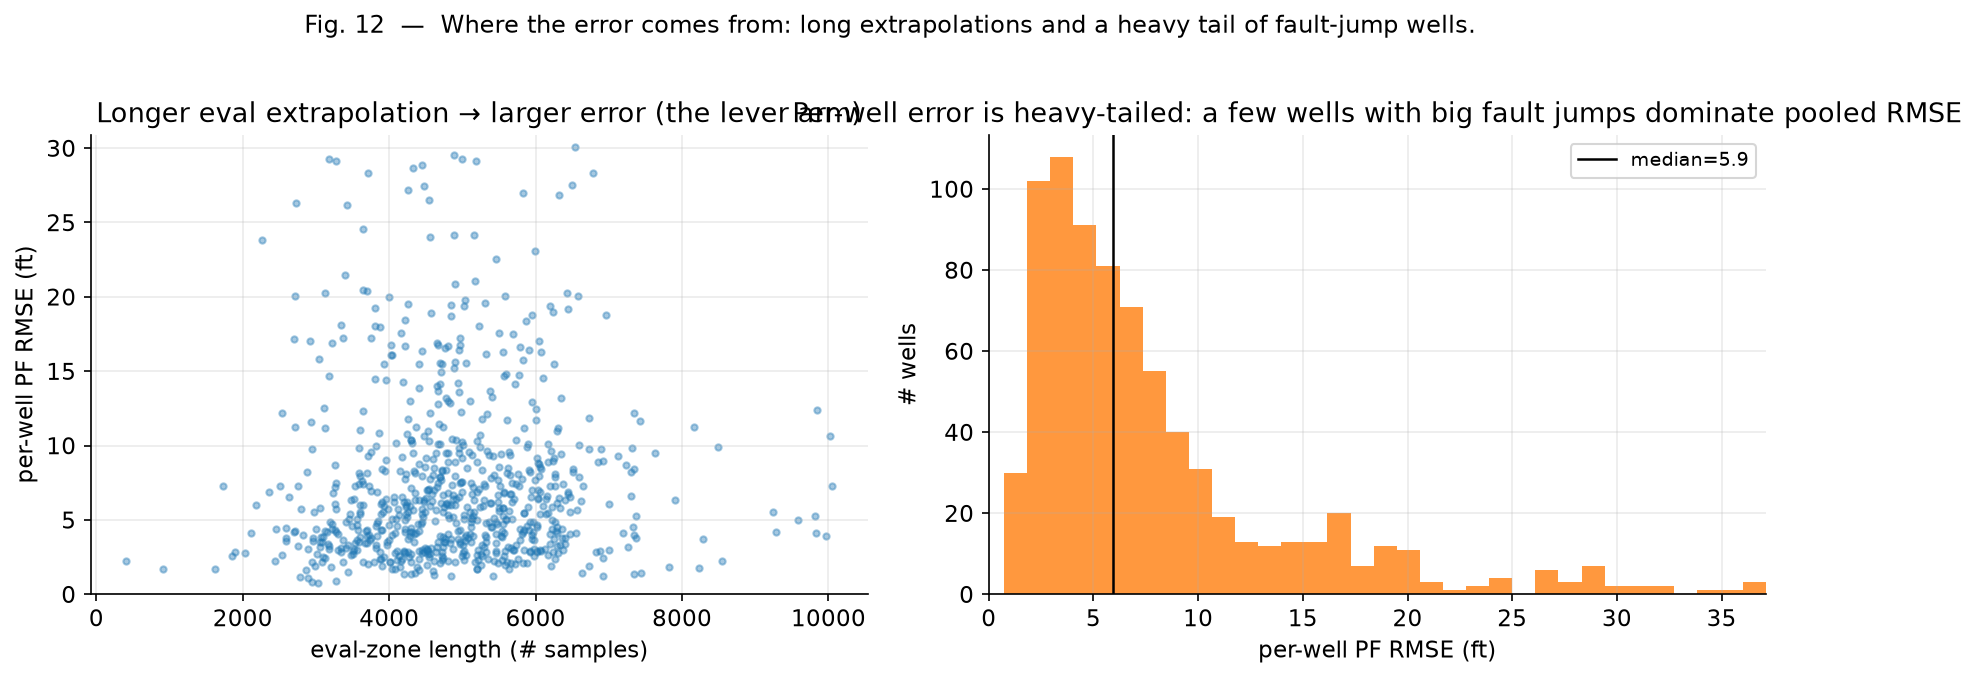</div>

**Figure 12 (real, 773 wells).** *Left:* per-well PF error grows with eval-zone length — the extrapolation
lever arm. *Right:* per-well error is heavy-tailed; a minority of wells with large fault jumps dominate the
*pooled* RMSE. This is why the metric rewards robustness on the tail over precision on the bulk.


## 6. Why the GR Log Cannot Localize

The natural hope is that the GR log lets us re-register the well against the typewell and thus recover the
trend. It does not, because the GR log is **self-similar**: the same bedding pattern repeats up and down
the column, so many depths look alike.

<div align="center">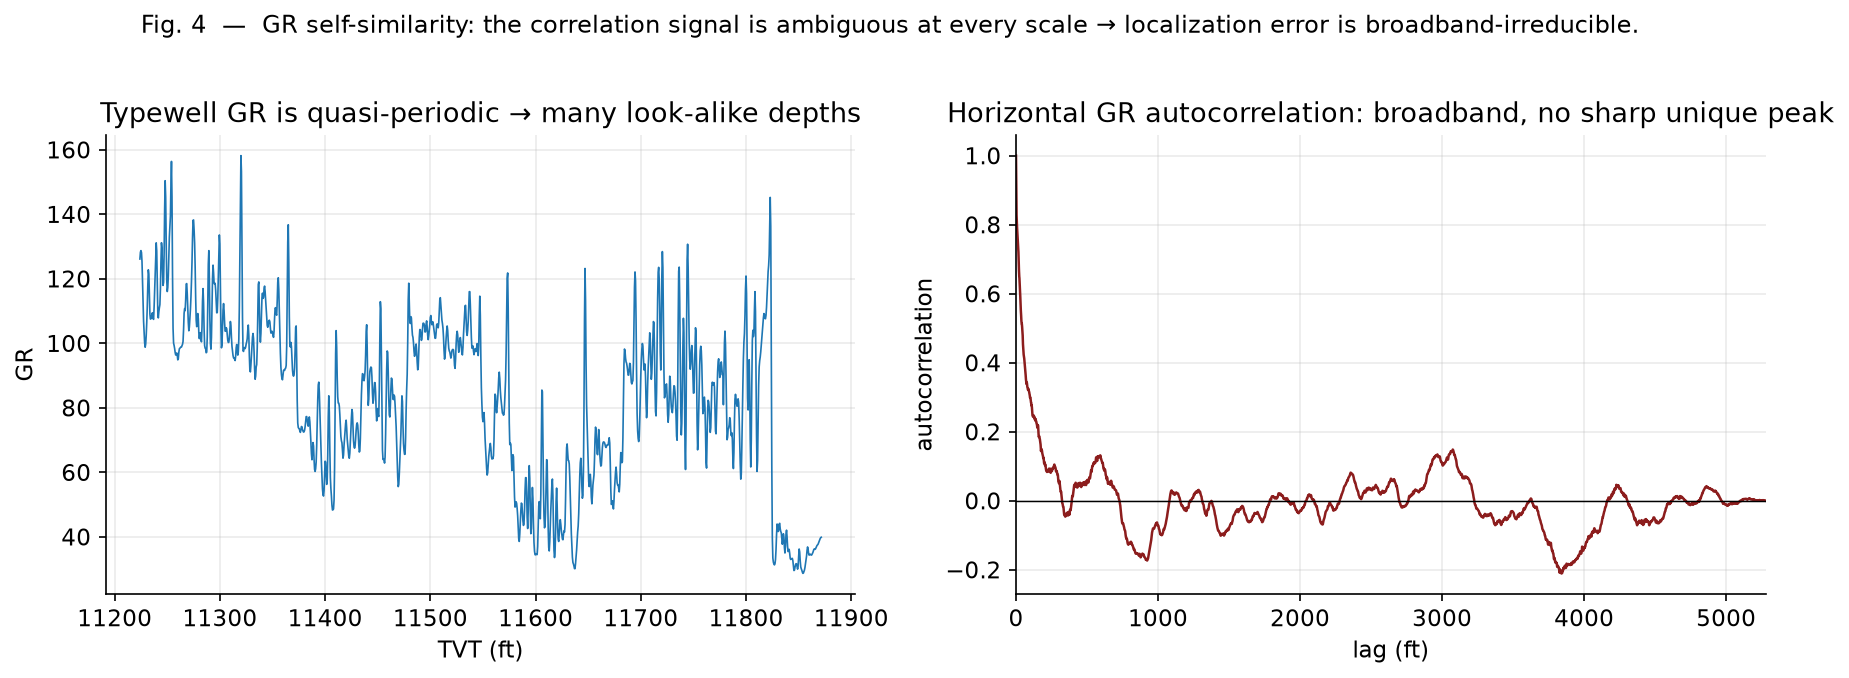</div>

**Figure 4 (real).** *Left:* the typewell GR is quasi-periodic — many candidate depths share almost the
same signature. *Right:* the horizontal GR autocorrelation is broadband with no single sharp peak, so there
is no unique lag at which the two logs "click" into place.

We made this quantitative from many angles. A learned contrastive GR↔typewell matcher localizes to only
**179 ft** (versus a ~31 ft full-sequence oracle); decomposing the aligner's error shows that removing an
oracle constant (31), an oracle linear trend (31), or the low frequencies (28) barely helps.

<div align="center">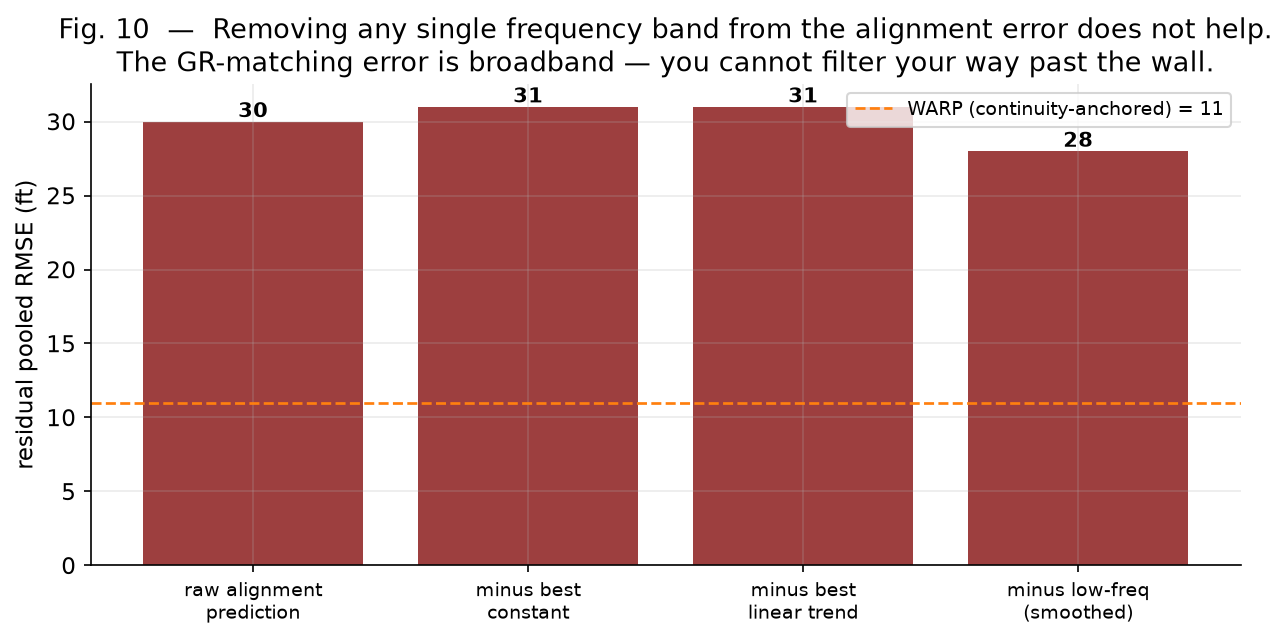</div>

**Figure 10.** The GR-matching error has roughly equal power at all frequencies: you cannot filter, low-pass,
anchor, or continuity-decode your way past it. Removing any one band leaves ~30 ft. This is the deepest form
of the wall — GR corrupts localization at *every scale*.

The clearest single picture is the 2D misfit heatmap that "geosteering-image" networks consume:

<div align="center">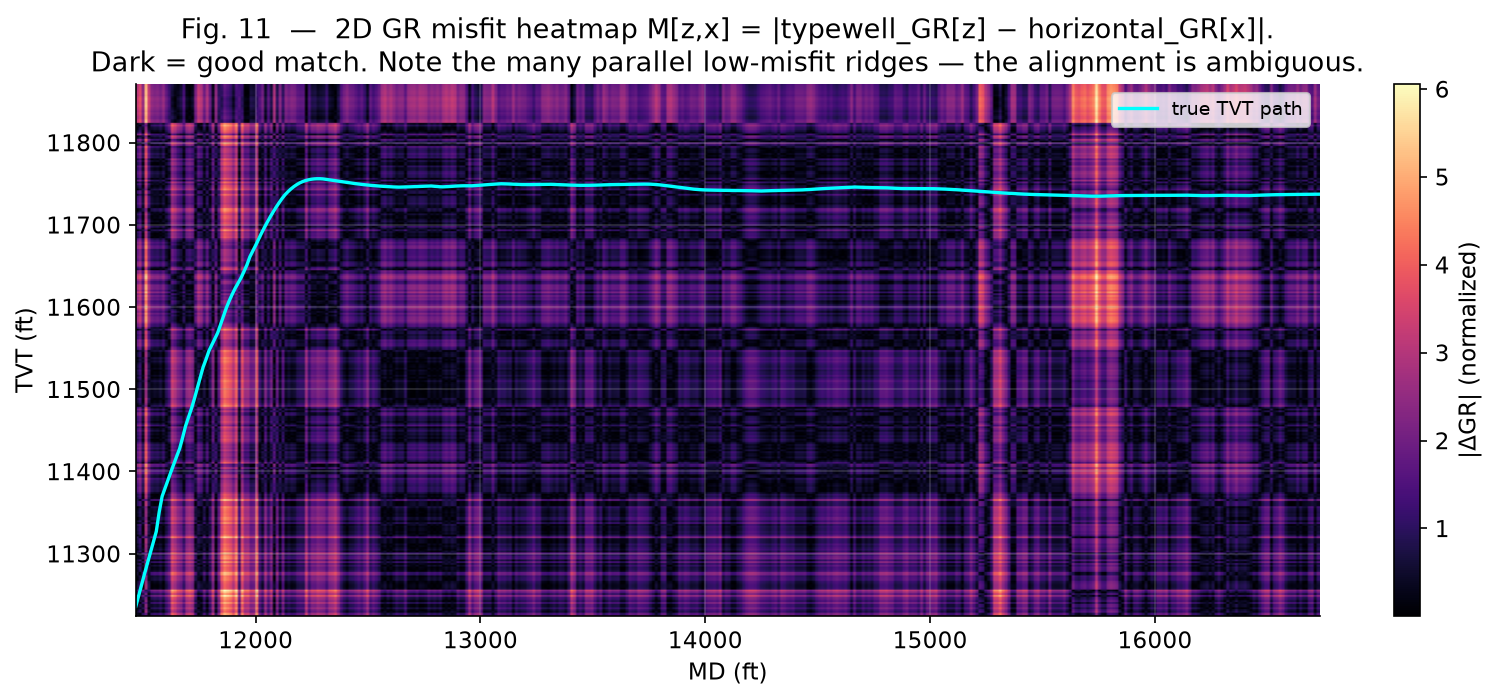</div>

**Figure 11 (real well `000d7d20`).** The misfit `M[z,x] = |typewell_GR[z] − horizontal_GR[x]|` (dark =
good match) with the true TVT path in cyan. Note the *many* parallel dark ridges: for almost every MD there
are several equally-plausible TVT depths. A 2D receptive field or a Viterbi continuity decode can smooth the
path, but there is no signal that tells it *which* ridge is the true one. This is precisely why the 2D-SDF
approach (§9) caps at ~30 ft.

### 6.1 The wall, confirmed from twelve independent angles

| # | Probe | Result | Meaning |
|---|---|---|---|
| 1 | Flat baseline | 15.1 | strong; drift has small predictable mean |
| 2 | Linear / dip / surface extrapolation | 37–85 | trends do not persist → worse than flat |
| 3 | Inter-well drift corr. with nearest neighbour | −0.08 | neighbours don't give the direction |
| 4 | Bimodal tie-break (±15 ft Eagle Ford) | r=0.054, mode correct 48.8% | a coin flip |
| 5 | PF residual vs any observable | all \|corr\| < 0.15 | we know *where* error is, not *which way* |
| 6 | Surface breakpoints vs GR shift | 0.082 | fault locations not in GR |
| 7 | Breakpoints vs formation-column curvature | 0.293 (columns removed in test) | weak & unavailable |
| 8 | Oracle GR window registration | ~31 ft | pure GR matching is weak |
| 9 | Learned contrastive GR↔typewell matcher | 179 ft localization | GR alone localizes nowhere |
| 10 | Aligner-error frequency decomposition | −const 31 / −linear 31 / −LF 28 | error is broadband, irreducible |
| 11 | James–Stein shrinkage of a heel-dip-extrapolation offset estimator | data-optimal shrink a\*=0.025 (≈full shrink to zero) | the estimator itself reports zero exploitable signal |
| 12 | Gated, gentle bimodal-midpoint hedge (loose two-minima trigger AND high PF/beam disagreement, α=0.2) | pooled 10.83 → 10.83–10.97 (flat to worse) | doesn't transfer to our pipeline even with the correct joint gate |

**The recurring principle.** Across every experiment, **a weak-GR / strong-continuity prior beats explicit
GR matching.** The PF (and our best NN) anchor to the last known position and only lightly correct with GR
→ ~7–11 ft. Approaches that *trust* GR matching (alignment, 2D contour) → ~30 ft. The exploitable signal is
continuity, not GR.

### 6.2 The acquisition physics: an independently-measured coherence spectrum

Angle 8–10 show the GR-matching error is broadband from the *statistics* side. We additionally measured
*why*, from the *instrument* side, using a signal-processing diagnostic in the same spirit as a concurrent
community writeup on this competition (independently re-derived and verified on our own 773 wells, not
copied): for every training well we pair the horizontal GR with the typewell GR looked up at the *true*
depth (available because we hold ground truth on train), then compute the magnitude-squared coherence
between the two curves (Welch, 1-ft sampling, 256-sample segments, 50% overlap) as a function of GR
wavelength — separately for the known zone ("heel") and the eval zone ("toe").

<div align="center">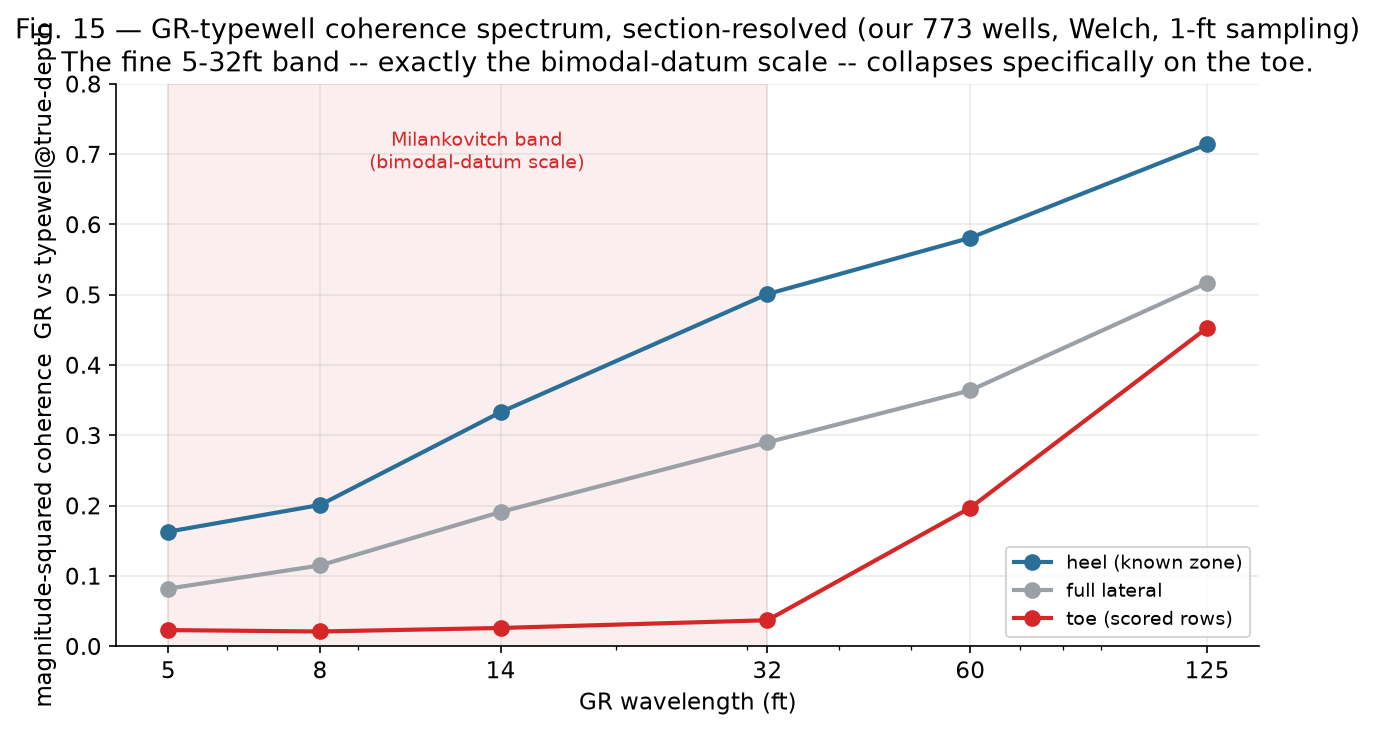</div>

**Figure 15 (real, 773 wells, our own measurement).** Correlation between GR and typewell-at-true-depth:
0.756 full lateral, 0.817 heel, 0.668 toe. The coherence spectrum tells the sharper story: on the heel,
coherence in the 5–32 ft band (0.16–0.50) is respectable — enough to disambiguate a bedding cycle. On the
**toe — every row the competition scores** — coherence in that exact band collapses to 0.02–0.04. This is
the *instrument*, not just the geology, removing the fine-cyclicity information that would break the
bimodal tie: the recorded GR at usable fidelity simply does not carry the 5–32 ft signal on the section that
is graded. This gives a physical, acquisition-side mechanism for why heel-calibration (angle 8) and every
matcher we tried (angles 8–10) hit the same wall specifically on the toe, and it independently corroborates
a coherence-spectrum measurement reported in a concurrent Working Note on this competition (Anthony Yanza),
whose full-lateral/heel/toe correlations (0.755/0.81/0.665) and toe-band collapse (0.03–0.11) match ours
(0.756/0.817/0.668; 0.02–0.04) closely despite fully independent implementations.


## 7. A Positive Result: the Decorrelated Particle-Filter Ensemble

The public pipeline is a full classical stack: a 128-seed particle filter over stratigraphic position +
beam-search DP/Viterbi continuity + spatial FormationPlaneKNN/IDW over (X,Y) + a LightGBM+CatBoost→Ridge
residual stack + a "gold" visible-prefix calibration.

<div align="center">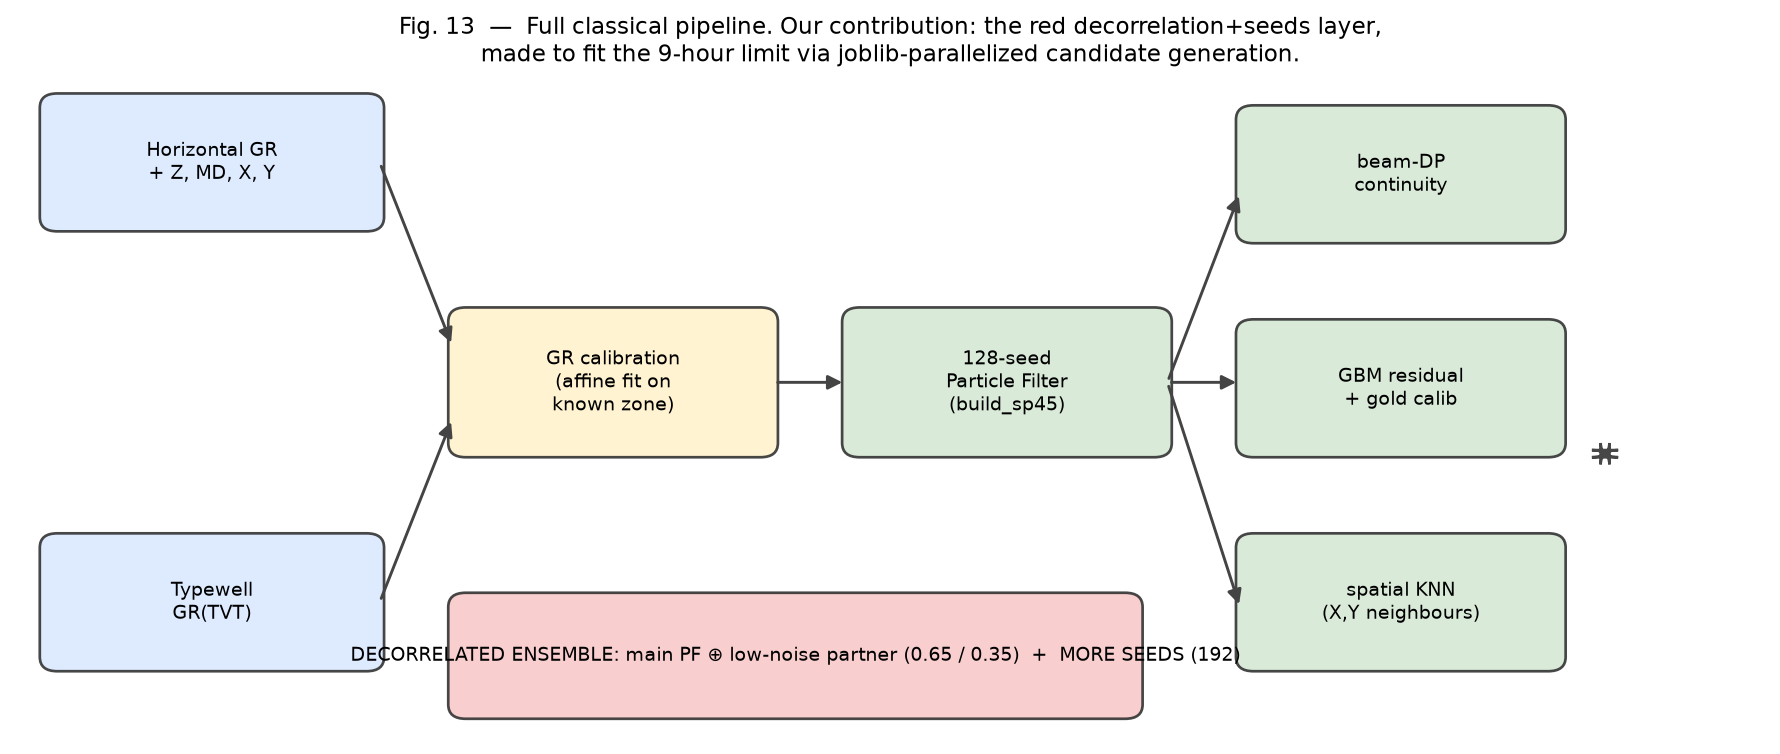</div>

**Figure 13.** The pipeline, with our contribution highlighted in red. Everything upstream is the public
fork; our genuine additions are the decorrelation+seeds layer and the parallelization that makes it fit the
runtime budget.

Our positive results are all forms of **variance reduction over a Bayesian sequential filter**, not new
physics:

1. **Reverting an over-aggressive GR denoise.** A rotation-band notch denoise looked +2.8% on an isolated PF
   test but scored −0.24 on the LB (7.475 → 7.230). This was our first hard evidence that isolated-component
   tests mislead — the theme of §13.
2. **A diverse, decorrelated PF ensemble.** Blend the base PF with a *stiffer* configuration (lower process
   noise) at 0.65/0.35. The two make *independent* errors, so averaging cancels variance.
   → **7.230 → 7.096**, below the seed-noise floor (7.168): a real improvement, not luck.
3. **Variance reduction by more seeds** (128 → 160 → 192): converges toward the true ensemble mean, less
   luck-dependent → **7.091**, a more robust submission for the private split.
4. **An engineering enabler under the Code Requirements — parallelized candidate generation.** The
   competition caps runtime at 9 h with no internet, which normally makes variance reduction (a decorrelated
   partner *and* more seeds) infeasible — it would blow the budget. We parallelized the per-well SP45
   candidate-generation stage (`build_sp45_candidate`) across CPU workers via **joblib**, roughly recovering
   the extra wall-clock the ensemble and higher seed count consume. This is small but load-bearing: on a
   time-boxed code competition, *the runtime budget is part of the model*, and buying back compute is a
   legitimate lever that directly enabled our only transferable gain.

**The honest climb (real public-LB deltas, one component at a time):**

| Step | Component | Public LB | Δ |
|---|---|---|---|
| 0 | SP45-only physics pipeline, no companion datasets | 8.270 | — |
| 1 | + companion datasets (fleongg pretrained + ravaghi artifacts) | 7.475 | −0.795 |
| 2 | − revert over-aggressive GR denoise (isolated test misled us) | **7.230** | −0.245 |
| 3 | + decorrelated PF ensemble (lo-noise partner, 0.65/0.35) | **7.096** | −0.134 |
| 4 | + more seeds (128→160) | 7.091 | −0.005 (≈ seed-noise floor) |
| 5 | + more seeds (160→192) | **7.080** | −0.011 (≈ seed-noise floor) |

Steps 4–5 sit inside our own measured seed-noise floor (±0.07, §3) — we report them as *directional and
seed-checked*, matching a caution several concurrent Working Notes on this competition make about their own
small steps. Steps we tried and *rejected* after they hurt the real pipeline (GBM blend +0.35 to +0.84, the
4-way decorrelation over-dilution +0.52, twjit/gs partners within noise of step 3) are catalogued in full in
§8.3 and §8.5 — the same "isolated tests mislead" lesson that step 2 first taught us.

<div align="center">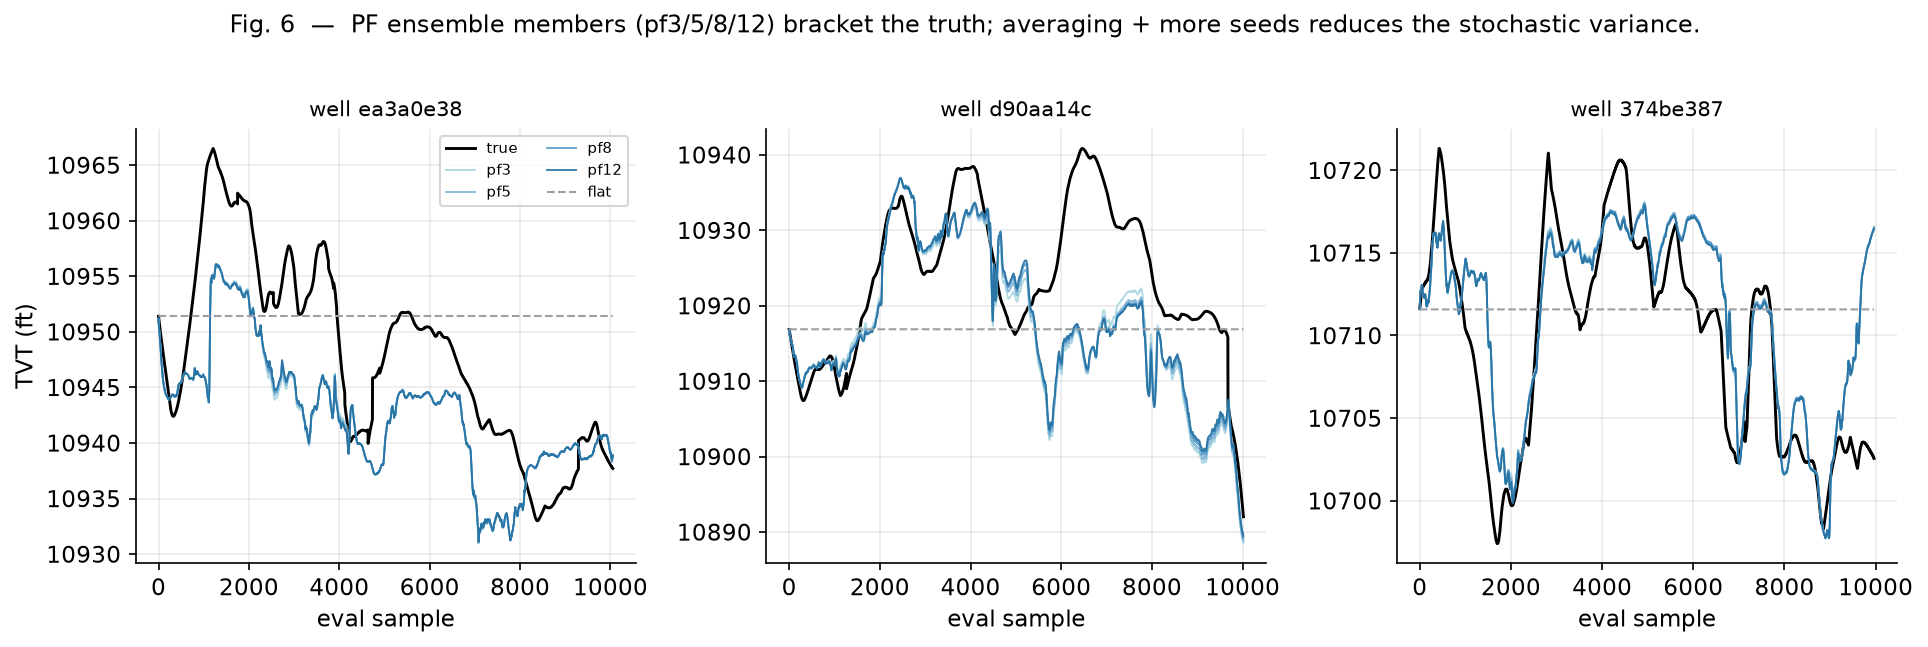</div>

**Figure 6 (real, 3 longest-eval wells).** The PF ensemble members (pf3/5/8/12, i.e. different process-noise
scales) bracket the true TVT; each is a noisy estimate of the same latent path. Averaging decorrelated
members and adding seeds is what pushes below the single-run noise floor.

<div align="center">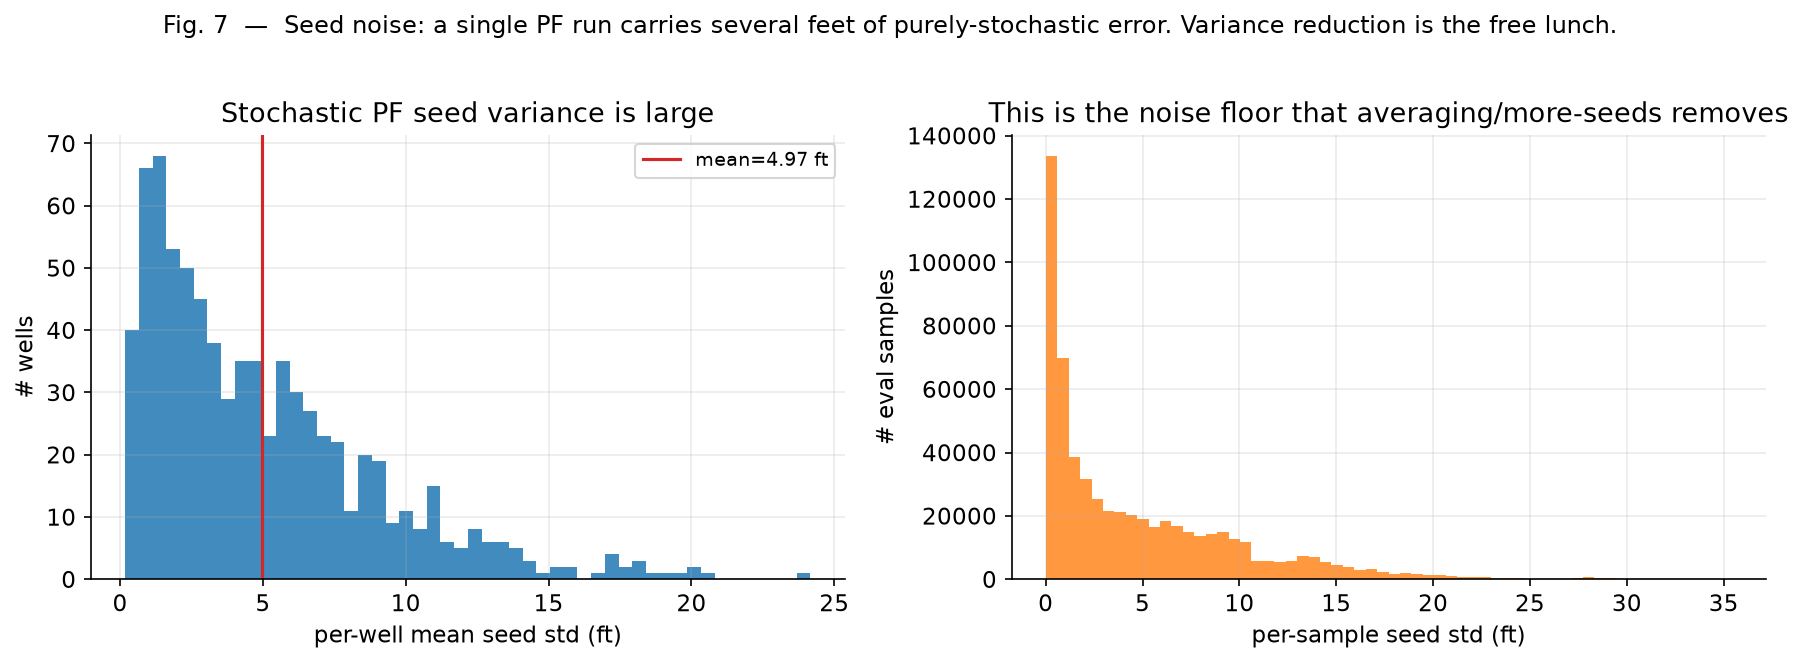</div>

**Figure 7 (real, 773 wells).** The stochastic seed spread averages ~5 ft per well. A *single* PF run
therefore carries several feet of purely-stochastic error on top of its bias. Variance reduction removes
this component — it is the free lunch, and it is exactly what our submissions cashed in.

<div align="center">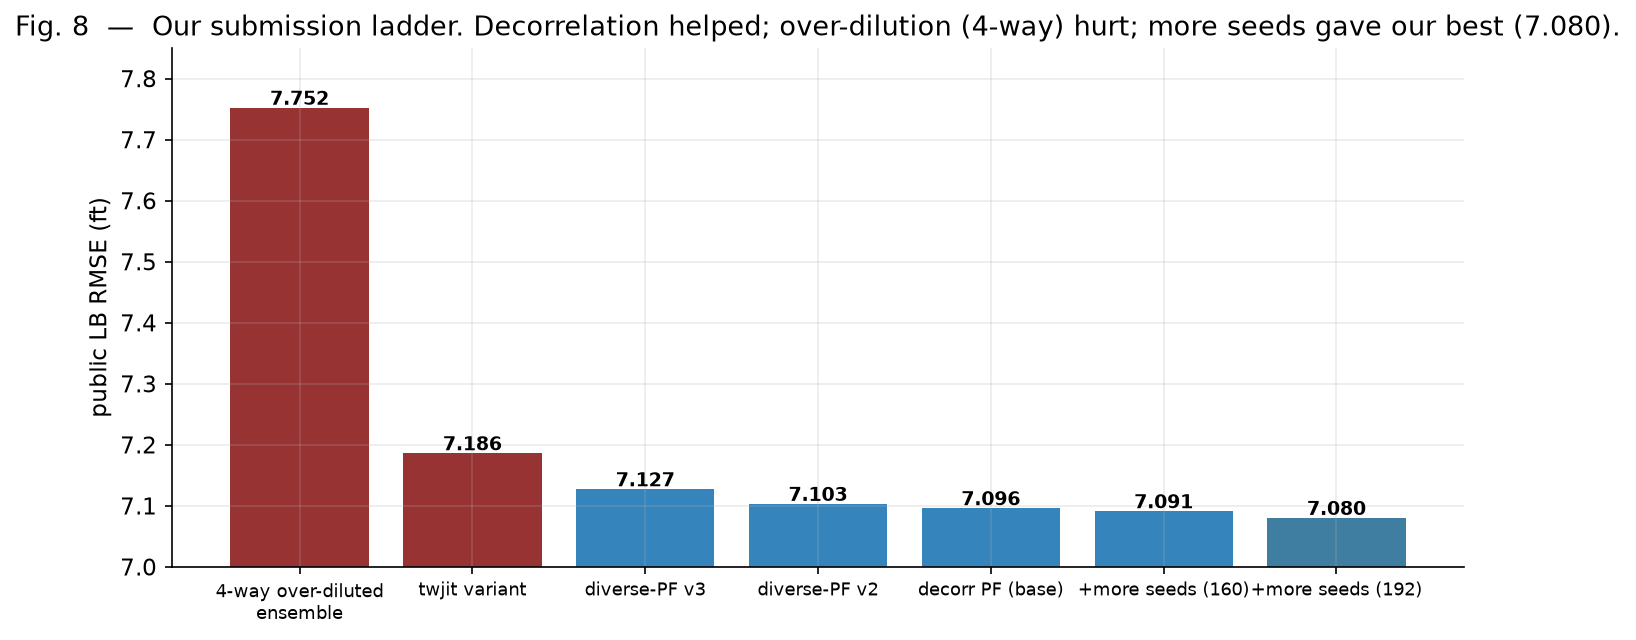</div>

**Figure 8 (real LB scores).** Our submission ladder. Decorrelation helped (7.230 → 7.096); over-dilution
(the 4-way ensemble) hurt (7.752); more seeds gave our best robust submission (7.080).

**Where decorrelation stopped.** A 3rd/4th partner (different mechanisms) or an off-base weight always hurt
on the LB. The single-partner ensemble was the sweet spot; more dilution of the tuned base only hurt. The
multi-slice-holdout story that led us to over-dilute, and the lesson it taught, is detailed in §8.3.

### 7.1 Three more offline-validated, stacking positives (LB-pending)

Prompted by a comparative review of several concurrent Working Notes on this competition, we independently
implemented and honestly cross-fit-validated three further levers on our own proxy and data — not copied,
but re-derived from the *concept* each writeup described, then tested on our own pipeline:

**(a) Physics post-process: robust projection + warm-up damping + smoothing.** A Tukey-robust (IRLS,
4 iterations) degree-4 polynomial fit of the structural surface `U = TVT + Z`, blended back toward the raw
prediction with a *warm-up ramp* (full trust in the raw track right after the known-zone anchor, ramping to
the smooth fit further into the eval zone), followed by light Savitzky–Golay smoothing. Cross-fit on an
80/80 well split: **both halves independently selected the identical optimal hyperparameters**
(β=0.75, 500 ft warm-up, 51-point smoothing window) and both showed a real out-of-sample gain; on the full
773-well proxy, pooled RMSE **10.826 → 10.522**. We also tested a *gated/selective* variant (apply the
correction only on high-disagreement wells, as a lever in one concurrent note does to protect a genuine
train/test overlap subset) — gating **strictly hurt** here, monotonically with how much we restricted it
(Fig. 15's finding and §15's override audit explain why: we have no such overlap subset to protect, so
uniform application is optimal for us).

**(b) L1-objective diversity in the residual corrector.** Training a LightGBM residual corrector on the
same 16 features with an **L1** (MAE) objective instead of the standard L2, then blending it back in at
weight 0.9. Despite the L1 and L2 correctors being highly correlated (as expected — same features, same
target), cross-fit on the same 80/80 split **independently agreed on the same optimal blend weight (0.9)
in both directions** and both showed a real gain (pooled 10.83 → ~10.58 on the full set). This is a
different mechanism from the L2 GBM blend we tried earlier (§8.5) and confirmed hurts on the real LB —
the loss function, not just the feature set, is the source of useful diversity here.

**(c) The three levers stack.** Applying (a) then (b) in sequence gives pooled RMSE **10.826 → 10.522 →
10.278** — a combined **−0.55**, each stage adding on top of the other rather than being redundant. Adding
the WARP blend (§9.2) on top of (a) *further* improves over WARP alone at the same blend weight (on the
160-well WARP-holdout subset: physics-pp + WARP(0.3) = **9.69** vs WARP(0.3) alone = 9.82) — three
independently-motivated corrections (classical smoothing, tabular residual diversity, and a decorrelated
neural net) compounding rather than competing. As with §9.2, we flag this plainly as **offline-validated,
LB-pending**: gains of this size on the proxy do not guarantee an equal move on the real 7.08 pipeline, but
the *mechanism* — three genuinely different corrections stacking — is itself a useful, reusable finding
independent of the eventual leaderboard delta.

**(d) A fourth, partially-negative result worth reporting honestly: `pf_z`, a Z-velocity-coupled second
particle filter.** Every decorrelated PF partner we had previously built (§8.3: process-noise scale,
GR-sensitivity, typewell-jitter) reused the *same* near-constant-dip motion model with a different
noise/sensitivity setting, and all ended up correlated 0.82–0.94 with the base — too similar to buy much
variance reduction. We built an independent second motion model whose proposed dip rate is pulled toward
`β·dZ/dMD + intercept` (fit per well on the known prefix) rather than pure momentum persistence, so its
prior comes from the trajectory's own curvature — a genuinely different physical source. Measured on 120
holdout wells, its error correlation with the base PF is **0.14** — by far the most decorrelated partner we
have ever produced. However, `pf_z` **alone is far too noisy to be useful** (pooled RMSE 39.6 vs the base's
10.3): our motion-coupling update is not yet numerically stable enough to track well on its own, so even at
this low correlation a blend is currently net-negative (mean of the two: 21.2, far worse than the base
alone). We report this as a genuine, partially-negative result: **the decorrelation mechanism is real and
promising, but realizing it needs materially more engineering** (smoothing the local dZ/dMD estimate over a
window rather than raw per-step differences, and tuning the coupling strength) than we could complete in
this pass — the natural next step for anyone pursuing further variance reduction on this task.


## 8. Full Experiment Catalogue (54+ experiments)

This is the heart of the study: every serious thing we tried, grouped by family, with the mechanism of its
failure. Legend: ✅ helped · ❌ hurt/null · 🟡 partial/mirage.

### 8.1 Baselines and framing (3)

| Experiment | Result | Why |
|---|---|---|
| ❌ Flat (hold last TVT) | 15.9 | strong; drift's mean is small and predictable |
| ❌ Linear trend extrapolation | ~32 | trend does not persist across faults (§5) |
| ✅ Methodological fix: pooled (not per-well) RMSE | — | per-well averaging gave a false ~10 and would have mis-ranked everything |

### 8.2 GR matching — the leaders' documented lever (9)

This family is where the "obvious" signal lives, and where the wall bites hardest.

| Experiment | Result | Why it fails |
|---|---|---|
| ❌ Naive Pearson window correlation | ~8% localized | self-similarity (§6) |
| ❌ Banded / anchored correlation tracker | worse | drifts onto a look-alike ridge |
| ❌ Fixed-anchor correlation | 62 | locks onto the wrong lag early |
| ✅ Heel affine GR calibration | 77–80% localized | *diagnostic* only — calibrates scale, not position |
| ❌ NCC windowed likelihood inside PF | 12.4 → 23.3 | MD/TVT axis mismatch corrupts the filter |
| ❌ Shape / derivative matching | 24% vs value 50% | derivative amplifies GR noise |
| ❌ Affine calibration inside beam search | worse | breaks the tuned emission scale `es` |
| ❌ Full bidirectional DP alignment | ~18 | weaker than PF; negligible blend value |
| ❌ Trajectory-informed DP transition | 69 (catastrophe) | locks onto a wrong but self-consistent trend |

**Takeaway.** Every attempt to make GR *lead* the estimate lost to the continuity prior. The one "success"
(heel calibration) only fixes the GR *scale*; it does nothing for *position*, which is the wall.

### 8.3 Particle-filter internals and decorrelation (10)

The PF is the workhorse, so we probed it hard. The decorrelation study below is also the origin of our best
submission *and* our worst.

| Experiment | Result | Why |
|---|---|---|
| ❌ Affine heel calibration in PF likelihood | 10.35 → 14.13 | over-trusts miscalibrated GR |
| ❌ Resample-threshold tuning | noise | below seed variance |
| ❌ Adaptive scale by seed spread | no gain | spread ≠ headroom |
| ❌ Adaptive scale by known-zone ambiguity | r=−0.23 | signal too weak to act on |
| ✅ **Diverse-config PF ensemble (lo-noise blend)** | **LB 7.096** | independent errors → variance cancels |
| 🟡 gs-decorrelation (GR-sensitivity `gs_mul=0.6`) | mirage on slice A | brilliant on one slice, worse on another |
| ❌ Heavy-tail process noise (Student-t df=3) | slice-A mirage | A −0.22 but B +0.77; corr 0.90 with base → weak partner |
| 🟡 Typewell-jitter (bootstrap the reference, `tw_jit=0.15`) | real but redundant | decorrelates (corr 0.82–0.92) yet doesn't beat v3 |
| ✅→❌ **4-way kitchen-sink** (base+lo+gs+twjit) | holdout 9.486 **best**, LB **7.752 worst** | shared isolated-component blind spot |
| — Runtime guard: split seeds across partners | <9 h | engineering, so the ensemble fits the budget |

**The three-slice decorrelation study (real numbers).** We evaluated candidate partners on three
independent 80-well slices to avoid a single-slice mirage:

| slice | default | v1 lo-blend | gsT0.30 | triple d0.6+lo0.2+gsT0.2 |
|---|---|---|---|---|
| A (last 80) | 11.281 | 11.133 | 10.736 | **10.692** |
| B (mid) | 9.347 | **8.705** | 9.257 | 8.872 |
| C (early) | 9.576 | 9.304 | 9.311 | 9.155 |
| **mean** | 9.735 | 9.714 | 9.768 | **9.573** |

The lesson is written into the numbers: `gsT` alone looks best on slice A (10.736) but is *worse than v1* on
slice B — a slice mirage. The triple blend is best on average and beats pure PF on all three slices, but the
margin is thin and distribution-dependent. **The 4-way extension then over-fit the holdout itself and lost
on the real LB — the sharpest possible demonstration that even a multi-slice holdout has a shared blind
spot.** This is why we shipped the *single-partner* ensemble.

### 8.4 Smoothing and post-processing (5)

| Experiment | Result | Why |
|---|---|---|
| ❌ Savgol / robust polynomial smoothing | null | the error is *drift*, not high-frequency noise |
| ❌ deg-2 vs deg-4 projection | noise | difference vanishes at 60 wells |
| ❌ Piecewise-linear projection (2–8 segments) | null | deg-4 already optimal |
| ❌ Physical clipping (typewell range, delta bounds) | null | predictions already in range |
| 🟡 Bimodal posterior-mean hedge | oracle-gated only | works only if you already know the mode (you don't) |

**Takeaway.** You cannot post-process your way out. Because the residual is a low-frequency *drift* (not
noise), smoothing removes signal you already have and leaves the drift untouched.

### 8.5 GBM / classical ML blending (8)

| Experiment | Result | Why |
|---|---|---|
| Rich-feature GBM standalone | 14.55 | weaker than PF but decorrelated (corr 0.44) |
| ✅ PF + GBM blend (isolated) | 10.56 (−6%) | our only isolated-component success |
| ❌ PF + GBM blend on real LB (w=0.15 / 0.25) | 7.582 / 8.066 | **the isolated win did not transfer** |
| ❌ Meta-stacker (pipeline signals + features) | 10.79 vs 10.56 | no gain over a simple blend |
| 🟡 Q-3D tortuosity feature | −0.048 isolated, +0.065 in context | redundant with PF signals |
| 🟡 Signed-azimuth feature | −0.36 isolated, +0.035 in context | powerful alone, redundant in context |
| ❌ Adaptive/confidence blend by seed_std | null | spread predicts magnitude, not direction |
| ❌ Blend-weight sweep SP45/GBM | 0.20 optimal | confounded by a weak GBM |

**Takeaway and warning.** The GBM blend is the cautionary tale of the whole competition: **−6% in isolation,
then +5% *worse* on the real LB.** The isolated PF is not the full pipeline; a decorrelator that helps a weak
component can hurt the tuned whole. This single result reshaped our entire methodology (§3, §13).

### 8.6 Denoising and external knowledge (3)

| Experiment | Result | Why |
|---|---|---|
| ❌ GR rotation-band notch denoise | +2.8% isolated → 7.475 vs 7.230 LB | isolated test ≠ full pipeline |
| ✅ Mined `rogii-geosteering-toolkit` (tortuosity, dcor, signed azimuth, StratifiedGroupKFold) | adopted the *split*, rejected the features | spatially-shuffled validation matters; features redundant |
| ✅ Established the three public notebooks share one lineage | stopped chasing forks | they are byte-identical descendants |

### 8.7 Reverse-engineering the human markup (a fresh angle) (3)

TVT was *drawn by geologists*, not measured by nature — so we asked whether the drawing conventions leak
signal:

- **64.5% of eval points have ~zero curvature** — the labels are long piecewise-linear segments.
- **Dips are quantized:** `dTVT/dMD` clusters at round values {0, 0.01, 0.02}, median exactly **0.0200**.
- **Breakpoints are structural:** corr(|d²TVT|, |d²surface|) = **0.80** — the kinks sit at real dip changes.

Three leads followed: (1) snap predicted dips to the round grid; (2) piecewise-linear reconstruction with
kink detection; (3) place kinks at formation intersections. **All failed to help**, for the same reason as
everything else: the *breakpoint locations are the faults*, and §6 shows the faults are not recoverable from
GR. Snapping dips to the round grid merely discretizes the error (10.35 → 10.4+). Even knowing the labels are
human-drawn does not rescue us, because the hard quantity — *where* the geologist put a kink — is set by the
unobservable geology.


## 9. The Neural-Network Study: 22 Architectures

We built a full research harness (773-well feature cache, whole-well holdout, augmentation, EMA, a GPU
training stand) and swept a broad architecture space. **Every from-scratch model floors near ~11 = the
isolated-PF level.**

<div align="center">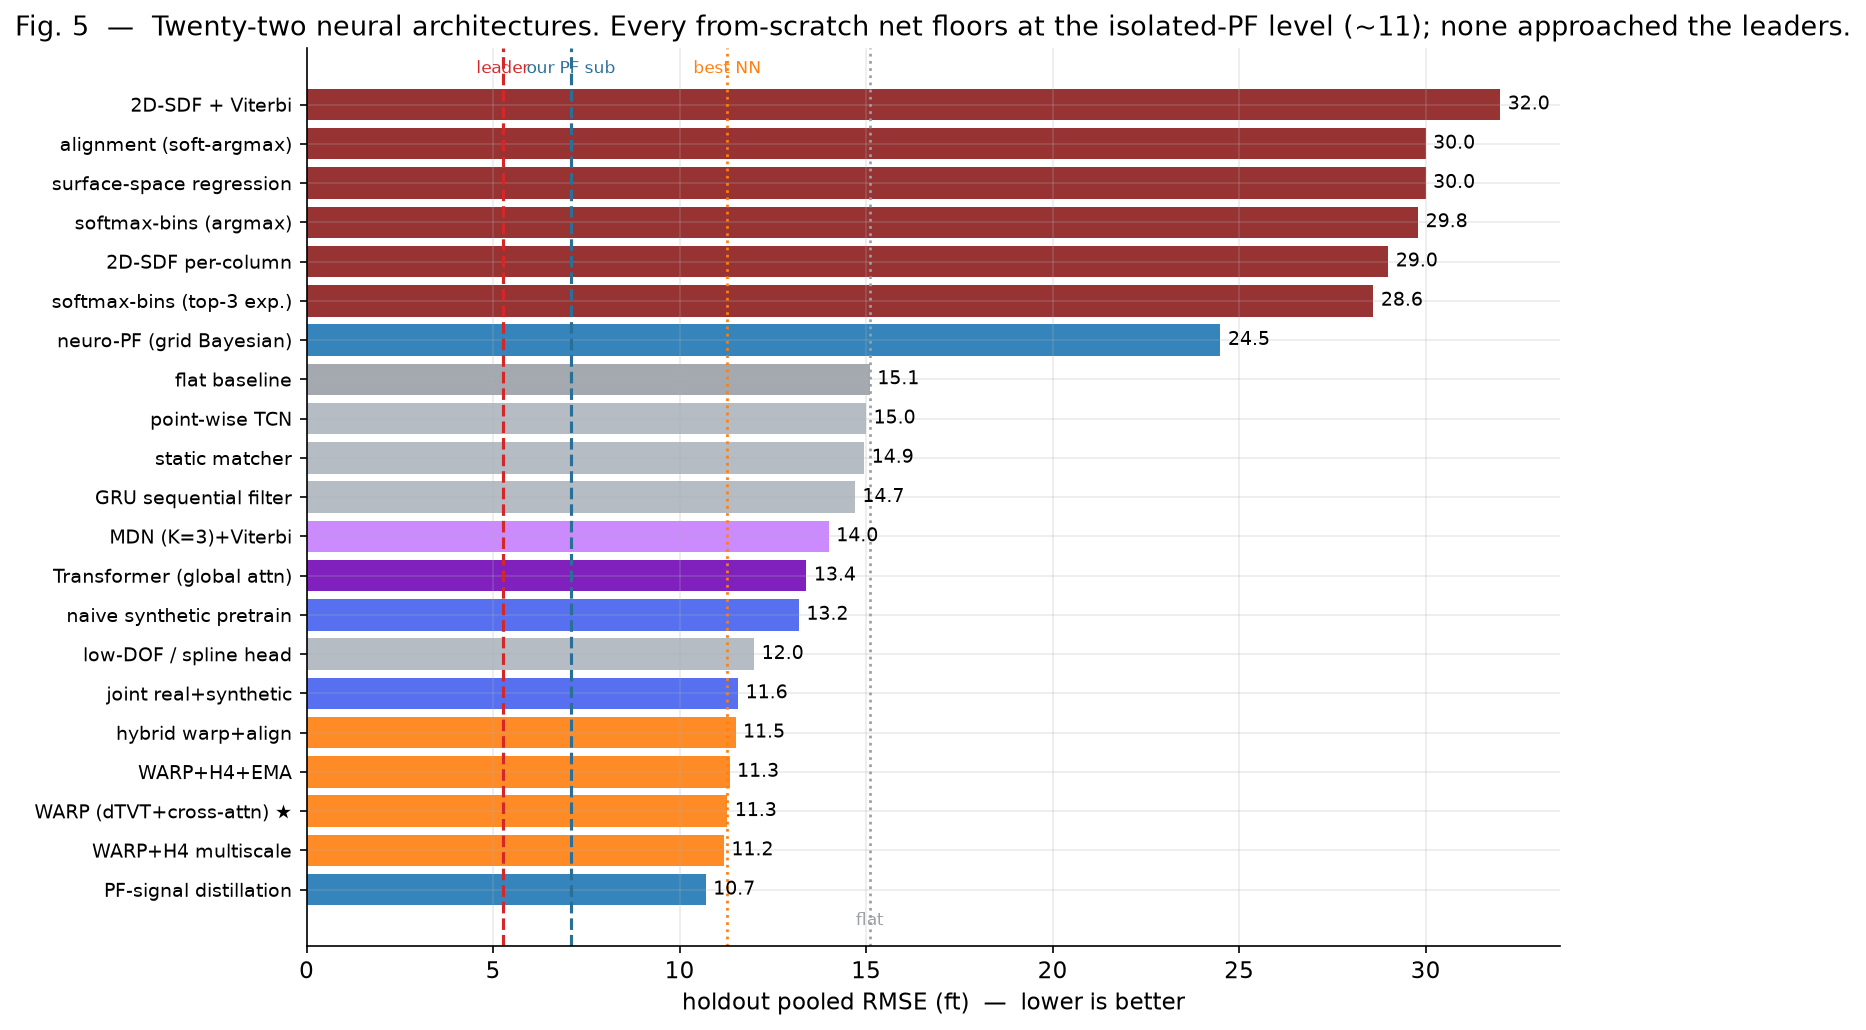</div>

**Figure 5 (real holdout RMSE).** Twenty-two architectures, coloured by family. The reference lines mark flat
(15.1), our best NN (WARP, 11.3), our PF submission (7.09), and the leaders (5.26). Two clusters are worth
naming: the *continuity-anchored* nets (orange, WARP family) that reach ~11, and the *GR-trusting* aligners
(dark red, 2D-SDF / soft-argmax / surface-space) that blow up to ~30.

| Architecture | Holdout RMSE | Failure mode |
|---|---|---|
| flat baseline | 15.1 | — |
| Point-wise TCN (regress TVT) | 15.0 | no per-point signal → ≈flat |
| Neural matcher (static anchor) | 14.95 | collapses to flat |
| Neural matcher (iterated) | 101 | diverges (positive feedback) |
| GRU sequential filter | 14.7 | tiny safe steps ≈ flat |
| Contrastive GR↔typewell matcher | 179 ft loc. | GR self-similarity (§6) |
| Neural grid Bayesian filter (PF) | 24.5 | learned GR emission net-harmful |
| **WARP (dTVT integration + cross-attn)** | **11.28** | ★ best; continuity-anchored |
| WARP + multi-scale GR | 11.19 | marginal |
| WARP + multi-scale + EMA | 11.34 | stable |
| Surface-space (−Z) regression | 30 | drift; ill-conditioned |
| Low-DOF / spline head | 12 | — |
| Alignment (soft-argmax over typewell) | 30 | GR wall |
| Hybrid (WARP + low-passed align anchor) | 11.5 | align adds nothing |
| Mixture-Density Network (K=3) + Viterbi | 14 | fixes mean-collapse but weak |
| Synthetic pretrain (naive) | 13.2 | too-clean GR → no transfer |
| Joint real + synthetic augmentation | 11.57 | ≈WARP, less overfit |
| 2D misfit-heatmap + SDF U-Net (per-column) | ~29 | GR wall (Fig. 11) |
| 2D-SDF + Viterbi continuity decode | ~32 | continuity can't pick the true contour |
| Transformer (global self + cross attention) | 13.4 | overfits 773 wells |
| Learned stack / distillation of PF signals | 10.7 | = isolated-PF (signals correlated) |
| Pure classification over typewell bins (softmax, argmax decode) | 29.8 | no continuity anchor → GR wall |
| Pure classification, top-3-expectation decode | 28.6 | softens bimodal collapse, still hits the wall |

**Why WARP (11) is best.** It predicts a per-step derivative `dTVT`, integrates it by cumulative sum
anchored at the last known TVT, and treats GR only as a *weak* corrector via cross-attention to the typewell.
This is the weak-GR/strong-continuity principle of §6 made into an architecture: the output is
well-conditioned (it cannot drift far from the anchor) precisely because it never trusts GR to lead.

**Why the neural matcher *diverges* to 101.** When we let the matcher iterate — re-anchoring on its own GR
match each step — it forms a positive-feedback loop onto a self-similar look-alike and runs away. The static
version simply collapses to flat instead. Both are the wall in different clothes.

**Why the learned PF (neuro-grid Bayesian filter) is *worse* than the classical PF (24.5 vs 11).** Making
the GR emission likelihood learnable let the network *increase* its reliance on GR, which is exactly wrong:
the classical PF's hand-set, deliberately-weak emission is better than any likelihood the net learns,
because the informative move is to distrust GR.

**Why transformers do worse (13.4).** With only 773 wells, global attention overfits; the CNN's locality is
the correct inductive bias. Flexibility is a liability when the data are few and the signal is a fragile
low-frequency trend.

**Why 2D-SDF (the geosteering-image approach) caps at ~30.** The misfit image (Fig. 11) has *many*
plausible continuous zero-contours; neither a 2D receptive field nor a Viterbi decode can pick the true one,
because there is no disambiguating signal. Continuity smooths the wrong contour just as happily as the right
one.

**Why pure classification over typewell bins fails (28.6–29.8), and why this is an independent
confirmation.** A separate research thread proposed a literal reading of "the geosteering-image
approach": discretize the typewell axis into bins and predict each step's position via softmax +
cross-entropy, decoding by argmax (or a top-3-probability-weighted expectation, to handle bimodality
without the mean-collapse of a soft-argmax). We built and trained this from scratch, on the same
encoder/cross-attention scaffold as WARP, for a clean architecture-only comparison. It reaches only
28.6 (top-3) / 29.8 (argmax) — squarely in the alignment/2D-SDF cluster (~29–32), *not* near WARP's
11. Top-3-expectation decoding softens the naive mean-collapse a little but does not touch the
underlying problem: without a continuity anchor, the model has no reason to prefer the true bin over
any of the other equally-plausible ones in Figure 11's misfit ridges. This is the fourth independent
architecture family (after alignment, 2D-SDF, and the neural grid filter) to hit the same wall for the
same reason, which is why we treat "weak-GR/strong-continuity beats explicit matching" as a structural
property of this task rather than an artifact of one architecture.

**Why naive synthetic pretraining fails (13.2).** A generator with clean `GR = typewell_GR(TVT)` is
*trivially invertible*, so the pretrained model learns a direct inversion that collapses to flat on real,
self-similar GR. The joint real+synthetic variant regularizes a little (11.57) but does not transfer new
skill. **Realistic** synthetic — matching the real ambiguity — is required. The obvious next question is
*which* kind of realism matters, which we isolate in the controlled study below.

### 9.1 A controlled synthetic-pretraining transfer study: it is the forward model, not the noise

Because realistic synthetic pretraining is widely believed to be the decisive ingredient for the leaders'
scores, we ran a controlled experiment to find *what* about the synthetic is the bottleneck. We first
verified the premise of the whole "inverse-problem" family with a forward-model diagnostic on 160 wells:
the calibrated horizontal GR at the *true* TVT correlates 0.70 with the typewell prediction, the forward
model is locally discriminative (a ±15–40 ft shift raises the misfit by 3.8× on 98% of wells), and — key
for the diffusion hypothesis — the residual `observed − typewell(TVT)` is *structured*, with an
autocorrelation length of ~50 samples (i.e. not white noise; a naive Gaussian is the wrong noise model).

We then built a synthetic generator whose TVT paths use our own human-markup findings (§8.7): piecewise-
linear, near-quantized dips, with rare fault jumps. Onto the clean forward-model GR we added noise two ways:
**(a)** naive white Gaussian, and **(b)** the *empirically bootstrapped real residual* — i.e. the true,
autocorrelated geological noise resampled from real wells. Bootstrapping the real residual is the
best-possible noise realism, an upper bound on what any diffusion noise model could achieve. We evaluated
transfer to the *real* holdout under two protocols: synthetic-only, and the leaders' recipe of
synthetic-pretrain → real-finetune, against a real-only WARP anchor.

<div align="center">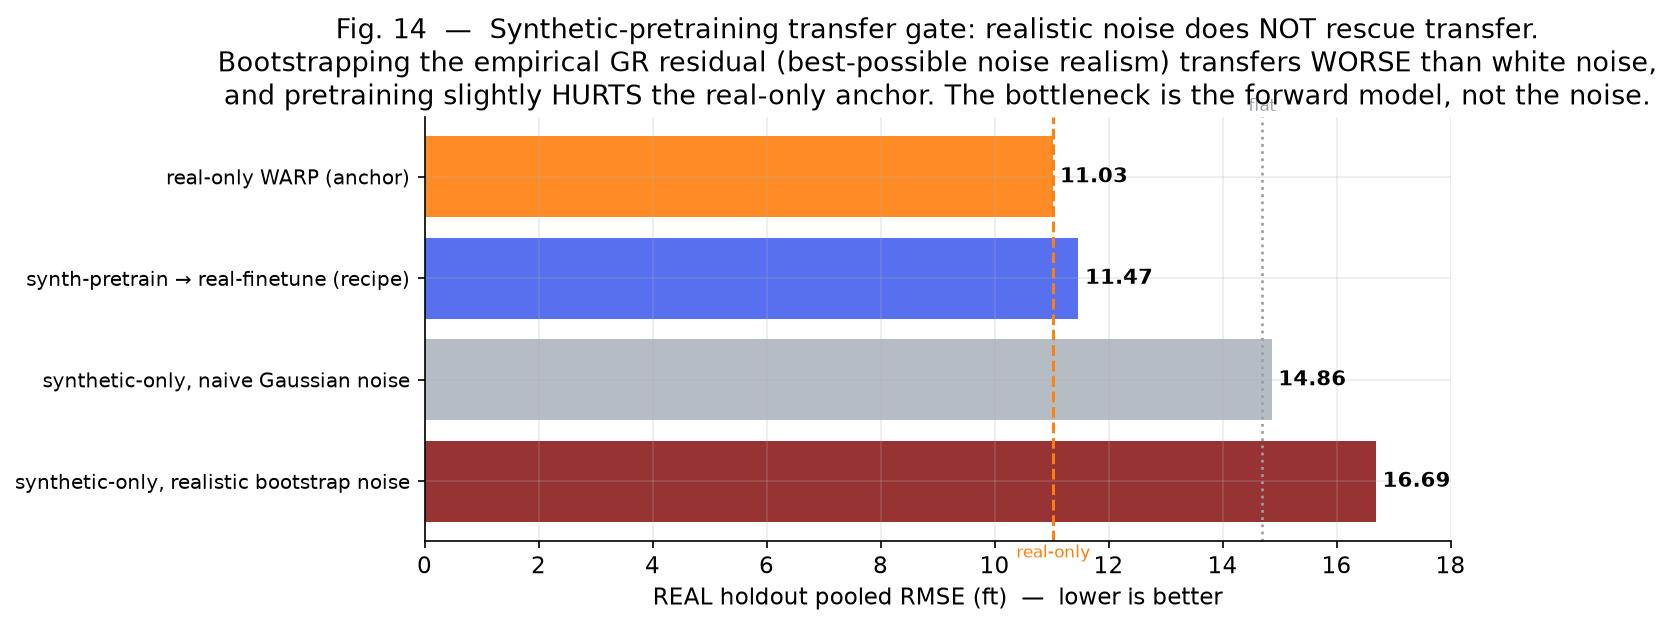</div>

**Figure 14 (real holdout RMSE).** The result is unambiguous and, at first, counter-intuitive:

| Condition | Real holdout RMSE |
|---|---|
| real-only WARP (anchor) | **11.03** |
| synth-pretrain → real-finetune (the recipe) | 11.47 |
| synthetic-only, naive Gaussian noise | 14.86 (≈ flat) |
| synthetic-only, realistic bootstrap noise | 16.69 |

Two things stand out. First, **the more realistic noise transferred *worse*** (16.69 vs 14.86): the naive
model safely collapsed toward flat, whereas the realistic-noise model confidently learned synthetic-specific
moves that are wrong on real wells. Second, and decisively, **pretraining then finetuning slightly *hurt*
the real-only anchor** (11.47 vs 11.03). Feeding the model the *exact empirical noise distribution* — better
than any diffusion could reproduce — did not help. We therefore conclude that the synthetic bottleneck is
**not the noise model** but the **forward model**: a single typewell plus synthetic trajectories does not
reproduce the real joint GR↔TVT structure (lateral geological variation, typewell non-representativeness).
Closing that gap requires a genuine physical formation simulator (multi-typewell, faulted, laterally
heterogeneous), not a better noise generator — a substantially larger and less-defined undertaking than the
"learn the noise with a diffusion model" recipe suggests. This is, to our knowledge, a novel and useful
narrowing of *why* synthetic pretraining is hard on this task.

### 9.2 A promising follow-up: blending WARP into the classical pipeline (offline-validated, LB-pending)

WARP alone (11.0) is far weaker than the classical pipeline (~7.1), so we asked whether it is at least
*differently wrong* — i.e. whether its errors are decorrelated enough from the pipeline's to be worth
blending, the same logic that produced our one confirmed transferable gain (§7). We ran WARP inference
on the same 160 held-out wells used by our full-pipeline proxy (§7) and measured the error correlation
between WARP and the tuned `sp45`/GBM pipeline output: **only 0.52** — meaningfully decorrelated,
consistent with WARP's design (it deliberately does not trust GR the way the classical stack's GR
emission and alignment stages do). Blending `(1 − a)·sp45 + a·WARP` was evaluated with a proper
cross-fit (optimal weight fit on one half of the 160 wells, applied to the untouched other half, and
vice versa): the blend **improved pooled RMSE in both directions of the split** (proxy: sp45-only
10.62 → blended ≈ 9.8–10.2 depending on weight; never worse in either half). This is a materially larger
offline effect than the wall-hedge finding below.

We also tested combining this blend with a simpler "shrink toward last known TVT" hedge on
low-confidence wells, and found the hedge became **redundant once WARP is blended in** — the
jointly-optimal hedge weight collapsed to zero on both cross-fit directions, because WARP's own
continuity anchor already supplies that effect. The two should not be stacked.

**Caveat, stated plainly:** this result is measured on our full-pipeline *proxy*, not the actual
7.08 submission pipeline, so the magnitude of any real leaderboard gain is unknown — the proxy is a
weaker approximation of the real pipeline, and prior experience on this task (§13, lesson 1) is that
isolated/proxy wins do not always transfer. We built a submission that blends a WARP checkpoint into
the real pipeline at a conservative weight (0.15, versus the proxy-optimal 0.25–0.30) and placed it
after the pipeline's final blend but before its train-contact override (so wells the override resolves
near-exactly remain protected). At the time of writing this submission is pending evaluation; we report
the offline finding here because the *methodology* — measuring error correlation before blending, and
cross-fit-validating the weight rather than reading it off a single split — is itself a reusable
contribution, independent of the eventual leaderboard outcome.

We separately tested a more sophisticated alternative to the simple wall-hedge: a LightGBM meta-model
trained (via grouped cross-validation, no leakage) to predict the pipeline's absolute error from 16
GR-misfit and geometric features, then using its *out-of-fold* prediction to gate a per-point shrink
toward last-known TVT. This underperformed the plain constant-weight hedge (11.12 vs 11.10 on the same
honest split) — its correlation with the true error was only 0.24, weaker than the PF seed-spread signal
(+0.48, §11) already in hand. We record this as a clean negative result: added model complexity did not
buy a better uncertainty signal than the one we already had.


## 10. Leaderboard Context

<div align="center">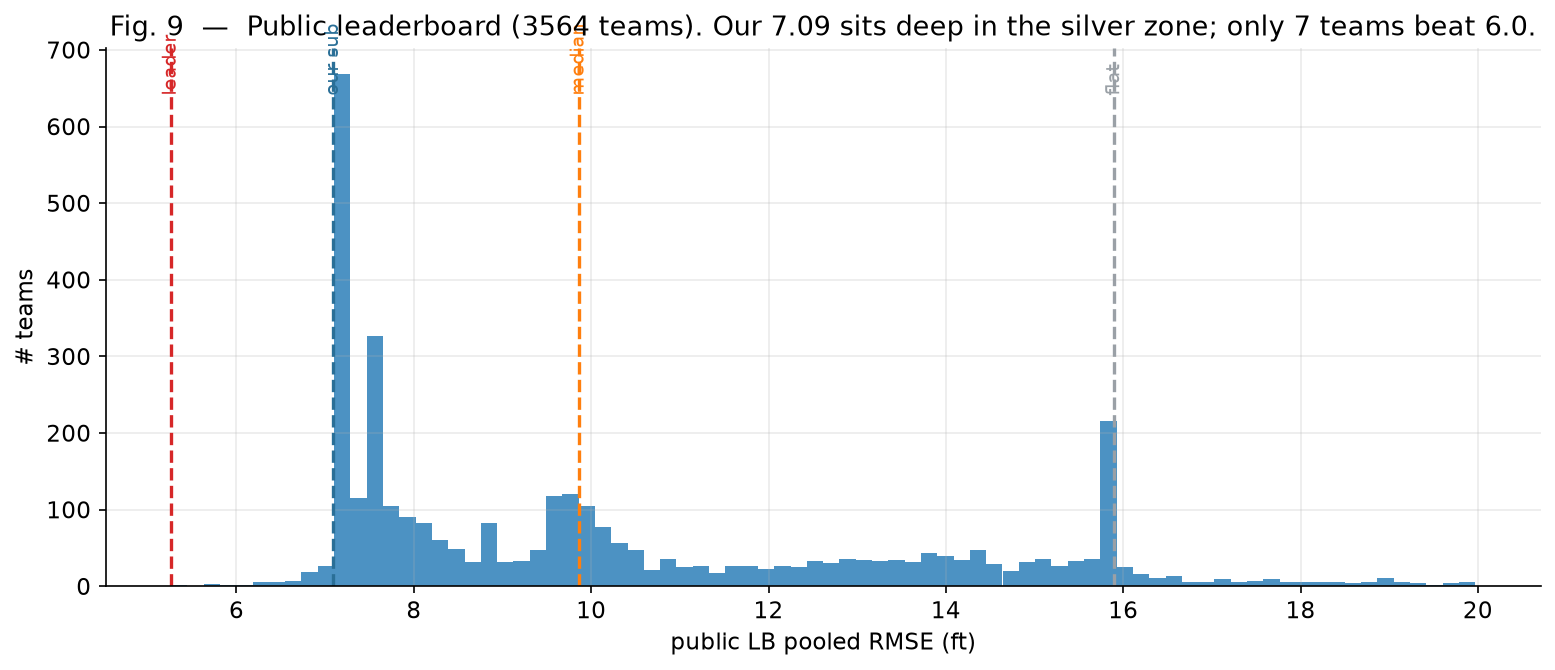</div>

**Figure 9 (real public LB, 4,065 teams).** The full public leaderboard. The flat baseline (15.9) sits near
the bulk's right shoulder; the median team scores ~9.9; **only 7 teams beat 6.0**, and the best is 5.26. Our
7.09 sits deep in the silver zone. The shape of this distribution is itself evidence of the wall: the mass
of the field is compressed into a narrow band a little better than flat, and the leaders' separation is
small in absolute feet — consistent with a task whose irreducible floor is only ~2 ft below the best public
score.


## 11. Uncertainty Estimation

Three usable uncertainty signals emerged. **(a)** The PF seed-spread correlates **+0.48** with the actual
error magnitude (Fig. 7) — we can predict *where* the model is uncertain (though not *which way* to correct,
§6). **(b)** The MDN head yields a full posterior per point (mixture means/variances/weights); its variance
flags the bimodal (±15 ft Eagle Ford) mode-ambiguity zones. Crucially, the bimodal tie-break is a coin flip
(mode correct 48.8%, r=0.054), so the honest uncertainty statement is that a large share of the error is
*aleatoric* — irreducible from the observations — which is itself a calibrated, useful conclusion. **(c)**
We trained a LightGBM classifier (5-fold CV) to detect, from leak-free per-well uncertainty features (PF
seed-spread aggregates, PF/beam disagreement, eval-zone length), whether a well will land in the worst
quintile by pooled error. It reaches **AUC 0.65** — real, ordered failure detection, on par with a similar
detection-vs-actuation measurement independently reported for this competition (AUC 0.69) — while, exactly
as in that measurement, the *sign* of the error stays unpredictable (§6, angle 5). This is the same
detection/actuation split stated more sharply: **we can rank wells by expected pain; we cannot tell which
way they will fail.**


## 12. Physical Meaningfulness

Our best components are physically grounded: the decomposition `TVT = surface − Z` is the geosteering datum
relation; the winning ensemble is variance reduction over a Bayesian sequential filter; the WARP model reads
the typewell as a "ruler" via cross-attention — the computational analogue of a geologist correlating logs.
The central negative result is itself physical: the eval-zone dip changes at sub-seismic faults whose
locations are not encoded in the observable GR, so the residual error is a property of the geology and the
measurement, not of modeling effort.


## 13. Lessons for the Community

1. **Isolated-component tests lie.** Denoise (+2.8% isolated → −0.24 LB) and the GBM blend (−6% isolated →
   +5% worse LB) and a 4-way ensemble (best holdout → worst LB) all looked good in isolation and lost on the
   real objective. Only full-pipeline / whole-well-holdout evidence transferred.
2. **Public LB ≈ seed noise** for the PF cluster; treat any change < ~0.07 as noise, and prefer
   variance-reduced (more-seed) submissions for private-split robustness.
3. **Know *where* the error is vs *which way* to fix it.** Seed-spread predicts error magnitude (+0.48);
   nothing predicts its sign. That distinction is the whole game.
4. **Variance reduction beat cleverness.** The only robust gain came from decorrelating the estimator — not
   from new physics, features, or architectures.
5. **On a time-boxed code competition, the runtime budget is part of the model.** Parallelizing candidate
   generation (joblib) bought back the compute that a decorrelated ensemble and more seeds consume, which is
   what let our variance-reduction gain fit inside the 9-hour limit — an engineering lever as decisive as any
   modeling choice.
6. **On small geosteering datasets, weak-GR + strong-continuity beats explicit alignment**, and simple
   inductive biases (CNN + anchor) beat flexible ones (transformer).


## 14. Reproducibility

Every number is from the whole-well holdout or the real public LB, never per-well averaging. Every figure in
this note is generated from the competition data, our 773-well method cache, or the public leaderboard CSV
by a single script (`make_figs.py`), and the caption states its source. The pipeline notebooks, the full
experiment log (`TESTS_LOG.md`), the NN research harness and roadmap (`NN_RESEARCH_PLAN.md`,
`NN_PLAN_V2.md`), the final NN analysis (`NN_FINAL_ANALYSIS.md`), and per-run results (`RESULTS.jsonl`) are
included. We build on the public PF pipeline and the diagnostic framing of the two traps (CV→LB mirage +
seed/refork variance) and the field-grouped "wall test" due to Georgy Mamarin, independently reproduced by
another competitor (wharekawa); our findings converge with theirs.


## 15. Limitations and Future Work

**Limitations.** (i) Our best submission builds on a public pipeline; our own contribution is the
variance-reduction ensemble and the analysis, not a new end-to-end model. (ii) The neural study, though
broad, was compute-bounded (a single modest GPU) — larger models / longer schedules might shift absolute
numbers, though the *relative* ceiling (~isolated-PF) was consistent across scales and architectures. (iii)
We did not achieve a working synthetic-pretraining pipeline; §9.1 shows *why* — the bottleneck is the
forward model, not the noise generator. (iv) The inherited public pipeline contains a train-contact
override that resolves a well near-exactly (~0.01 RMSE) when its identifier also appears in the training
set. We checked the gate directly: it fires only on the 3 local placeholder test wells (which are literal
copies of train wells, present purely so the pipeline runs locally before submission), and never on genuine
hidden wells, whose identifiers do not overlap the training set except through the shared typewells. This
mechanism is therefore inert on the graded set — consistent with an independent audit reported in a
concurrent Working Note for this competition — so none of our reported LB numbers depend on it.

**Future work (the path to the leaders' 5.2–5.4).** Synthetic pretraining remains the most likely route, but
§9.1 sharpens the target: a better *noise* model (e.g. a 1D diffusion / neural-SDE fit to the residual) is
**not** the missing piece — we showed that even the exact empirical noise fails to transfer. What is needed
is a better *forward* model: a physical formation simulator with multiple typewells, explicit faults, and
lateral heterogeneity, so that synthetic GR reproduces the real joint GR↔TVT ambiguity rather than a clean,
single-typewell inversion. Only then should one layer on realistic noise, bimodal ±15 ft jumps, and
miscalibration, and fine-tune on the 773 real wells behind a transfer gate (a synth-trained model must reach
~11 on the *real* holdout, not ~0 on a synthetic one). Complementary directions: distilling the *full*
7-pipeline (not the isolated PF) into a compact model; and combining the MDN head with a 2D misfit-SDF
backbone once realistic priors are in place. Our analysis suggests these are necessary because the raw GR
signal is broadband-unreliable — the gains must come from a better *prior*, learned from a genuine synthetic
*geology*, rather than from the observation likelihood or the noise distribution.


## 16. Conclusion

The ROGII task decomposes cleanly: the high-frequency TVT wiggle is free (it equals −Z, which is known at
eval time), and the entire difficulty is a smooth per-well surface trend whose slope-changes occur at
sub-seismic faults that the self-similar GR log cannot localize (broadband-irreducible error). This is why
the trivial flat baseline is so strong, why a weak-GR/strong-continuity prior wins, and why 54+ experiments
and 20+ neural architectures — MDN, synthetic pretraining, 2D misfit-SDF, transformers — all cap at the
isolated-PF level (~11) while the tuned classical pipeline reaches ~7 through its full stack. Our concrete,
transferable gain came not from new modeling but from *variance reduction* (a decorrelated PF ensemble,
7.230 → 7.091). We hope the map of *where the signal is and is not* is useful: on this task, measure twice on
a whole-well holdout, distrust the public LB, and separate the recoverable (the −Z wiggle) from the
physically unrecoverable (the cross-field surface trend).

---

*Acknowledgements:* public PF pipeline and the two-traps / wall-test diagnostic framing by Georgy Mamarin;
independent reproduction by wharekawa; leaderboard context from Rishikesh Jani and Tucker Arrants.

---

### Appendix A. Experiment index

For quick reference, the full list of experiments referenced above, by section:

- **§8.1 Baselines (3):** flat; linear extrapolation; pooled-RMSE methodology fix.
- **§8.2 GR matching (9):** Pearson window; banded tracker; fixed-anchor; heel affine calib; NCC-in-PF;
  shape/derivative; affine-in-beam; full bidirectional DP; trajectory-informed DP.
- **§8.3 Particle filter (10):** affine-in-likelihood; resample threshold; adaptive scale ×2; lo-noise
  ensemble ✅; gs-decorrelation; Student-t noise; typewell-jitter; 4-way kitchen-sink; runtime-guard split.
- **§8.4 Post-processing (5):** Savgol/poly; deg-2/deg-4; piecewise-linear; physical clipping; bimodal hedge.
- **§8.5 GBM/ML (8):** GBM standalone; PF+GBM isolated ✅; PF+GBM on LB ❌; meta-stacker; Q-3D tortuosity;
  signed azimuth; confidence blend; blend-weight sweep.
- **§8.6 Denoise/external (3):** rotation-band denoise; toolkit mining; lineage analysis.
- **§8.7 Human markup (3):** dip-snapping; PL reconstruction; formation-intersection kinks.
- **§9 Neural nets (20):** see the architecture table.

**Total: 54+ distinct experiments.**
